# Among adults with T2DM initiating Metformin monotherapy, what demographic and clinical characteristics are associated with the _timing_ of second-line antidiabetic therapy initiation?

**Study Design:** Descriptive observational study of metformin users who subsequently initiated second-line antidiabetic therapy. Time to escalation is measured from the metformin index date to the first non-metformin antidiabetic prescription. 

**Cohort**: Extracted from SynPUF 5% using ATLAS and the query in `Scripts/cohort_raw.sql`. 334 days of data from `2009-01-15` - `2009-12-15`. Inclusion criteria:

- Must have T2DM.
- Must have a second-line drug initiated in the study period.
- Must be an adult (18+)
- No pregnancy 9 months before the start of, _and_ 60 days before the end of the study period (to prevent inclusion of gestational diabetes.) -- We are allowing people to get pregnant 2 months before the study end date.

**Covariates**:

- Age
- Sex
- Ethnicity
- CKD
- CHD
- Hypertension
- Depression
- Diabetes Duration

**Team:** Giselle Feng (`fg2618`) and Nikhil Anand (`na3213`)

In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import multivariate_logrank_test
from scipy import stats
import warnings

warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams.update(
    {
        "figure.figsize": (10, 6),
        "figure.dpi": 120,
        "font.size": 11,
        "axes.titlesize": 13,
        "axes.labelsize": 11,
    }
)

# Step 1 : Data Loading and Cleaning

In [122]:
def clean_and_prepare(filepath):
    """
    Load raw drug-exposure-level data and return two DataFrames:
      1. df_raw  — all exposures within the study window (for pathway analysis)
      2. df      — one row per patient, first escalation event (for survival analysis)
    """

    raw = pd.read_csv(filepath)
    print(f"Raw data: {len(raw)} rows, {raw['person_id'].nunique()} unique patients")

    # --- Parse dates ---
    date_cols = [
        "cohort_start_date",
        "cohort_end_date",
        "observation_period_start_date",
        "observation_period_end_date",
        "second_line_start_date",
        "second_line_end_date",
        "censor_date",
    ]
    for col in date_cols:
        raw[col] = pd.to_datetime(raw[col], errors="coerce")

    # --- Drop exposures outside the study window ---
    before = len(raw)
    raw = raw[raw["second_line_start_date"] <= raw["cohort_end_date"]].copy()
    dropped = before - len(raw)
    print(f"Dropped {dropped} exposures after study end date (cohort_end_date)")
    print(f"Remaining: {len(raw)} exposures, {raw['person_id'].nunique()} patients")

    # --- Standardize ---
    raw["second_line_drug_name"] = raw["second_line_drug_name"].str.strip().str.lower()
    raw["gender"] = raw["gender"].str.strip().str.upper()
    raw["race"] = raw["race"].str.strip()
    raw["ethnicity"] = raw["ethnicity"].str.strip()

    # --- Days from metformin start to each exposure ---
    raw["days_to_drug"] = (
        raw["second_line_start_date"] - raw["cohort_start_date"]
    ).dt.days

    # --- Flag anomalies ---
    neg = raw[raw["days_to_drug"] < 0]
    if len(neg) > 0:
        print(f"WARNING: {len(neg)} exposures with negative time. Removing.")
        raw = raw[raw["days_to_drug"] >= 0].copy()

    same_day = raw[raw["days_to_drug"] == 0]
    if len(same_day) > 0:
        print(
            f"NOTE: {len(same_day)} exposures on day 0 (same day as metformin start)."
        )

    # --- Study period length ---
    raw["study_period_days"] = (
        raw["cohort_end_date"] - raw["cohort_start_date"]
    ).dt.days

    # --- Save cleaned full dataset for pathway analysis ---
    df_raw = raw.copy()

    # --- Collapse to one row per patient: first second-line event ---
    raw = raw.sort_values(["person_id", "second_line_start_date"])
    df = raw.groupby("person_id").first().reset_index()

    # --- Time to first escalation ---
    df["time_to_escalation"] = (
        df["second_line_start_date"] - df["cohort_start_date"]
    ).dt.days

    print(
        "Number of records with zero time to escalation days",
        len(df[df["time_to_escalation"] == 0]),
    )
    print("These will be pruned!")
    df = df[df["time_to_escalation"] > 0]

    # --- Diabetes Duration ---
    df = df[df["diabetes_duration_days"] > 0]
    df["diabetes_duration"] = pd.cut(
        df["diabetes_duration_days"],
        bins=[0, 180, 365, 547, 730],
        labels=["0–6 mo", "6–12 mo", "12–18 mo", "18–24 mo"],
    )
    df["diabetes_duration"] = pd.Categorical(
        df["diabetes_duration"],
        categories=["0–6 mo", "6–12 mo", "12–18 mo", "18–24 mo"],
        ordered=True,
    )

    # --- Event indicator (all = 1, everyone escalated) ---
    df["event"] = 1

    # --- Age groups ---
    df["age_group"] = pd.cut(
        df["age_at_index"],
        bins=[17, 44, 64, 74, 120],
        labels=["18-44", "45-64", "65-74", "75+"],
    )

    # --- Rename flags ---
    df = df.rename(
        columns={
            "hypertension_flag": "hypertension",
            "depression_flag": "depression",
            "chd_flag": "chd",
            "ckd_flag": "ckd",
        }
    )
    df_raw = df_raw.rename(
        columns={
            "hypertension_flag": "hypertension",
            "depression_flag": "depression",
            "chd_flag": "chd",
            "ckd_flag": "ckd",
        }
    )

    print("Removing any records where the time to escalation equals the study period")
    df = df[df["study_period_days"] > df["time_to_escalation"]]

    print(f"\nPatient-level data: {len(df)} patients")
    print(f"  Median time to escalation: {df['time_to_escalation'].median():.0f} days")
    print(
        f"  Range: {df['time_to_escalation'].min()} – {df['time_to_escalation'].max()} days"
    )

    return df_raw, df


df_raw, df = clean_and_prepare("../Data/cohort_raw.csv")
df.head()

Raw data: 25182 rows, 9951 unique patients
Dropped 8419 exposures after study end date (cohort_end_date)
Remaining: 16763 exposures, 9116 patients
NOTE: 1867 exposures on day 0 (same day as metformin start).
Number of records with zero time to escalation days 1860
These will be pruned!
Removing any records where the time to escalation equals the study period

Patient-level data: 4679 patients
  Median time to escalation: 67 days
  Range: 1 – 326 days


,person_id,gender,race,ethnicity,age_at_index,cohort_start_date,first_t2dm_date,diabetes_duration_days,cohort_end_date,observation_period_start_date,...,depression,chd,ckd,censor_date,days_to_drug,study_period_days,time_to_escalation,diabetes_duration,event,age_group
3,82,MALE,White,Not Hispanic or Latino,81,2009-05-01,2008-01-05,482,2010-03-31,2008-01-05,...,0,1,0,NaT,38,334,38,12–18 mo,1,75+
4,83,FEMALE,White,Not Hispanic or Latino,46,2009-05-30,2008-05-16,379,2010-02-16,2008-02-08,...,1,1,0,2010-02-16,132,262,132,12–18 mo,1,45-64
7,142,FEMALE,White,Not Hispanic or Latino,72,2009-01-27,2008-01-30,363,2009-12-27,2008-01-24,...,0,0,0,2010-06-06,250,334,250,6–12 mo,1,65-74
8,147,FEMALE,White,Not Hispanic or Latino,83,2009-06-21,2008-06-05,381,2010-05-21,2008-01-18,...,0,1,1,NaT,135,334,135,12–18 mo,1,75+
10,178,MALE,White,Not Hispanic or Latino,81,2009-03-18,2008-02-24,388,2010-02-15,2008-01-17,...,1,1,1,2010-04-14,34,334,34,12–18 mo,1,75+


# Step 2: Descriptive Analysis

## Data Distributions

### Baseline Characteristics

In [123]:
def make_table(df):
    rows = []
    N = len(df)

    # --- Continuous: Age ---
    med = df["age_at_index"].median()
    q1 = df["age_at_index"].quantile(0.25)
    q3 = df["age_at_index"].quantile(0.75)
    rows.append(("Median Age at Index (IQR)", f"{med:.0f} ({q1:.0f}–{q3:.0f})", ""))

    # --- Continuous: Time to escalation ---
    med_t = df["time_to_escalation"].median()
    q1_t = df["time_to_escalation"].quantile(0.25)
    q3_t = df["time_to_escalation"].quantile(0.75)
    rows.append(
        (
            "Time to escalation (days), median (IQR)",
            f"{med_t:.0f} ({q1_t:.0f}–{q3_t:.0f})",
            "",
        )
    )

    rows.append(("", "", ""))  # spacer

    # --- Categorical variables ---
    cat_vars = {
        "Gender": "gender",
        "Race": "race",
        "Ethnicity": "ethnicity",
        "Age group": "age_group",
        "Diabetes Duration": "diabetes_duration",
    }
    for label, col in cat_vars.items():
        rows.append((f"**{label}**", "n", "%"))
        for val in sorted(df[col].dropna().unique()):
            n = (df[col] == val).sum()
            pct = n / N * 100
            rows.append((f"  {val}", str(n), f"{pct:.1f}%"))

    # --- Binary comorbidity flags ---
    rows.append(("", "", ""))
    rows.append(("**Comorbidities**", "n", "%"))
    for label, col in [
        ("Hypertension", "hypertension"),
        ("Depression", "depression"),
        ("CHD", "chd"),
        ("CKD", "ckd"),
    ]:
        n = df[col].sum()
        pct = n / N * 100
        rows.append((f"  {label}", str(int(n)), f"{pct:.1f}%"))

    # --- Comorbidity count ---
    df_temp = df.copy()
    df_temp["comorbidity_count"] = df_temp[
        ["hypertension", "depression", "chd", "ckd"]
    ].sum(axis=1)
    med_c = df_temp["comorbidity_count"].median()
    mean_c = df_temp["comorbidity_count"].mean()
    rows.append(
        (f"Comorbidity count (of 4), median (mean) {med_c:.0f} ({mean_c:.1f})", "")
    )

    table1 = pd.DataFrame(rows, columns=["Characteristic", "Value", ""])
    return table1


table = make_table(df)
print("TABLE 1: Baseline Characteristics")
print("=" * 60)
print(table.to_string(index=False))

TABLE 1: Baseline Characteristics
                                 Characteristic       Value       
                      Median Age at Index (IQR)  74 (67–82)       
        Time to escalation (days), median (IQR) 67 (30–127)       
                                                                  
                                     **Gender**           n      %
                                         FEMALE        2906  62.1%
                                           MALE        1773  37.9%
                                       **Race**           n      %
                      Black or African American         591  12.6%
                                          White        4088  87.4%
                                  **Ethnicity**           n      %
                         Not Hispanic or Latino        4679 100.0%
                                  **Age group**           n      %
                                          18-44         202   4.3%
                            

In [124]:
print("Diabetes Duration")
df["diabetes_duration_days"].describe()

Diabetes Duration


count    4679.000000
mean      350.229964
std       130.997943
min         1.000000
25%       272.000000
50%       362.000000
75%       439.000000
max       674.000000
Name: diabetes_duration_days, dtype: float64

### Time to Escalation

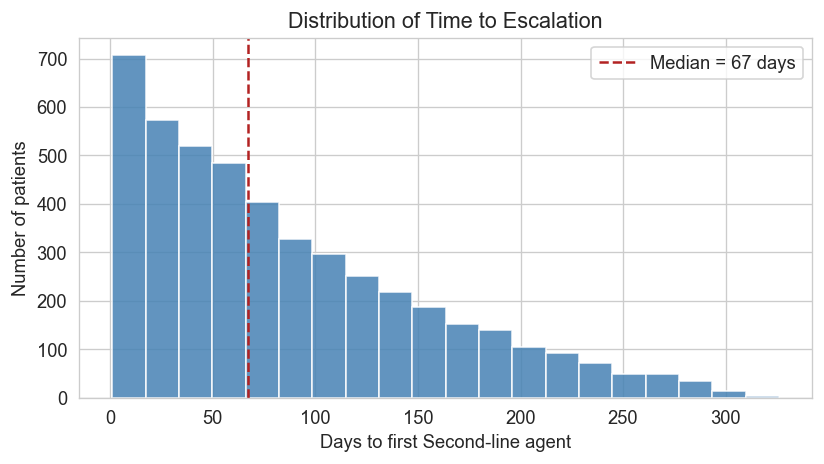

In [125]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(
    df["time_to_escalation"], bins=20, color="steelblue", edgecolor="white", alpha=0.85
)
ax.axvline(
    df["time_to_escalation"].median(),
    color="firebrick",
    linestyle="--",
    label=f"Median = {df['time_to_escalation'].median():.0f} days",
)
ax.set_xlabel("Days to first Second-line agent")
ax.set_ylabel("Number of patients")
ax.set_title("Distribution of Time to Escalation")
ax.legend()
plt.tight_layout()
plt.show()

### Demographics

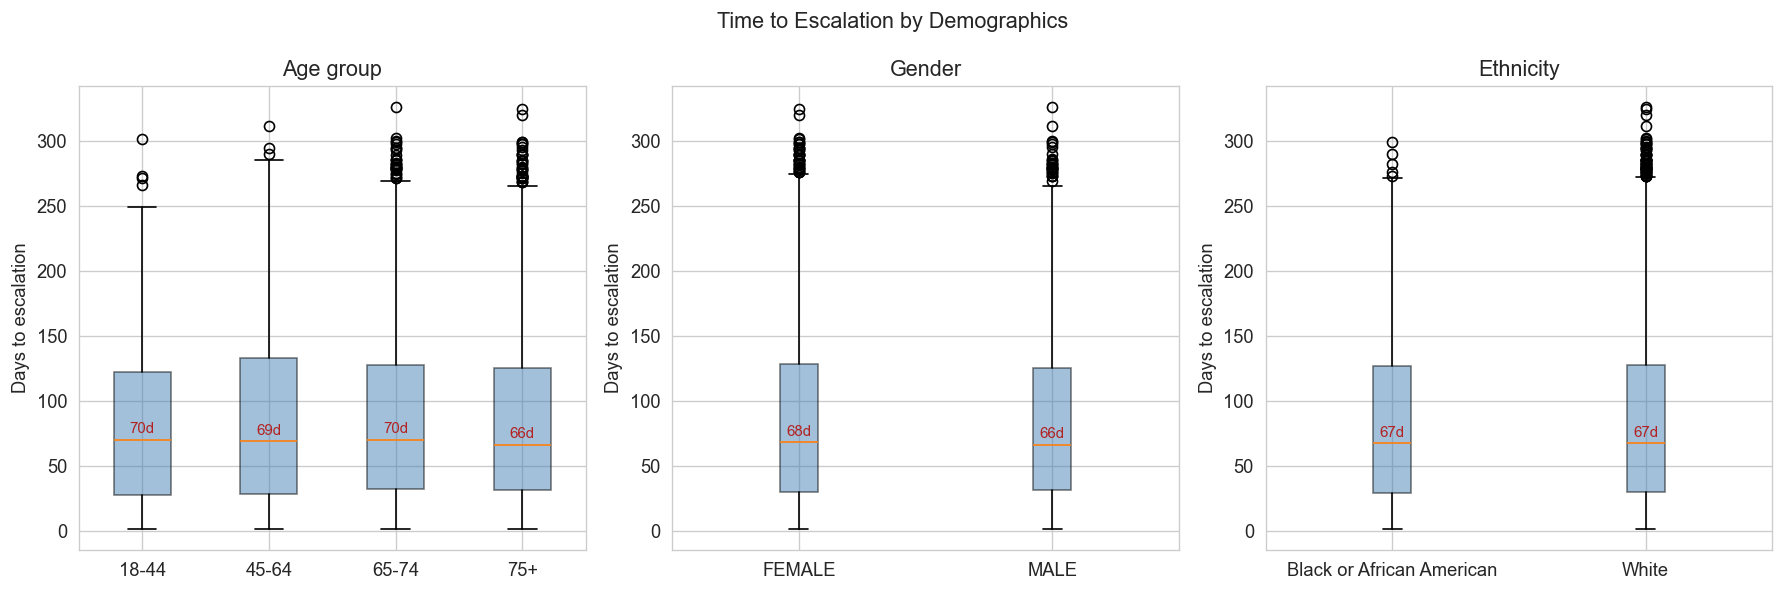

In [126]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (label, col) in zip(
    axes,
    [("Age group", "age_group"), ("Gender", "gender"), ("Ethnicity", "race")],
):
    grouped = df.groupby(col)["time_to_escalation"]
    keys = list(grouped.groups.keys())
    labels = [str(k) for k in keys]
    groups = [grouped.get_group(k).dropna().values for k in keys]
    ax.boxplot(
        groups,
        labels=labels,
        patch_artist=True,
        boxprops=dict(facecolor="steelblue", alpha=0.5),
    )
    ax.set_title(label)
    ax.set_ylabel("Days to escalation")
    ax.tick_params(axis="x")
    medians = grouped.median()
    for i, med in enumerate(medians.values):
        ax.text(
            i + 1, med + 5, f"{med:.0f}d", ha="center", fontsize=9, color="firebrick"
        )

plt.suptitle("Time to Escalation by Demographics", fontsize=13)
plt.tight_layout()
plt.show()

### Comorbidities

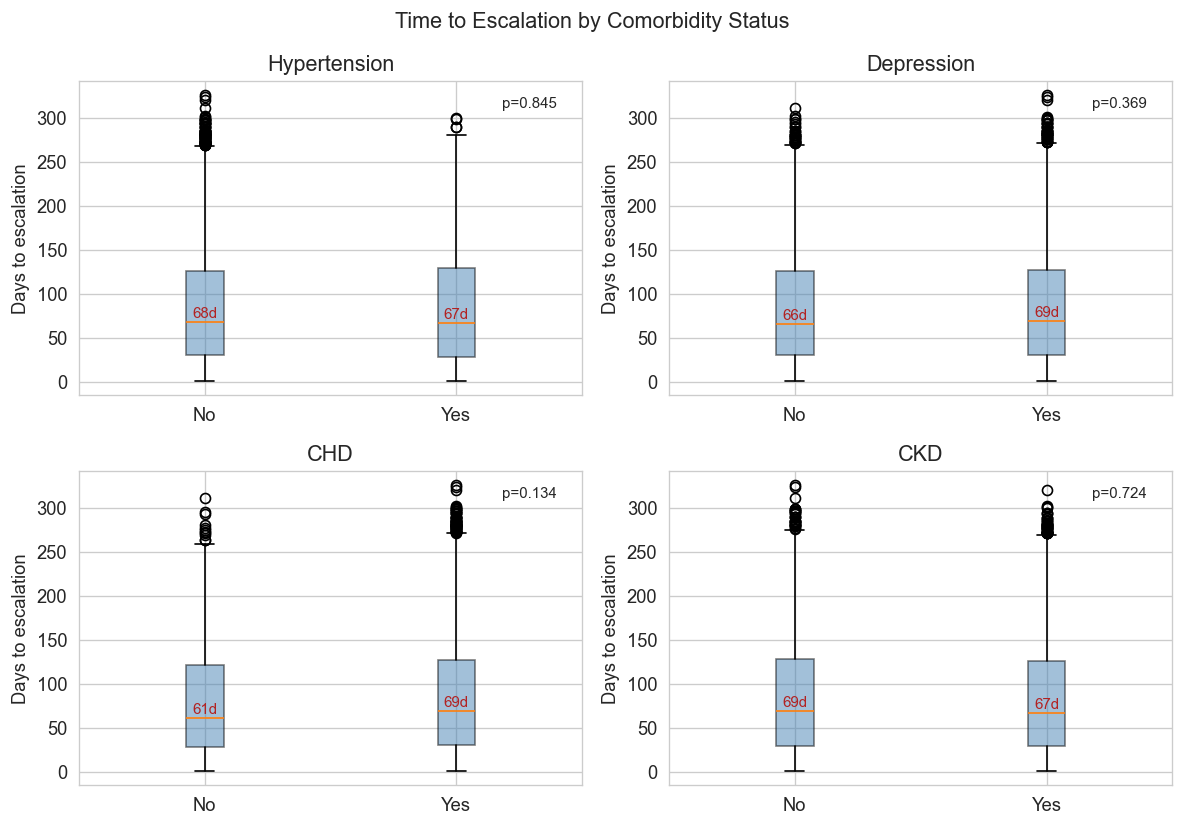

In [127]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for ax, (label, col) in zip(
    axes.ravel(),
    [
        ("Hypertension", "hypertension"),
        ("Depression", "depression"),
        ("CHD", "chd"),
        ("CKD", "ckd"),
    ],
):
    data_0 = df[df[col] == 0]["time_to_escalation"]
    data_1 = df[df[col] == 1]["time_to_escalation"]
    ax.boxplot(
        [data_0, data_1],
        labels=["No", "Yes"],
        patch_artist=True,
        boxprops=dict(facecolor="steelblue", alpha=0.5),
    )
    ax.set_title(label)
    ax.set_ylabel("Days to escalation")
    medians = df.groupby(col)["time_to_escalation"].median()
    for i, (grp, med) in enumerate(medians.items()):
        ax.text(
            i + 1, med + 5, f"{med:.0f}d", ha="center", fontsize=9, color="firebrick"
        )
    if len(data_0) > 0 and len(data_1) > 0:
        stat, p = stats.mannwhitneyu(data_0, data_1, alternative="two-sided")
        ax.text(
            0.95,
            0.95,
            f"p={p:.3f}",
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=9,
        )

plt.suptitle("Time to Escalation by Comorbidity Status", fontsize=13)
plt.tight_layout()
plt.show()

### Diabetes Duration before index date

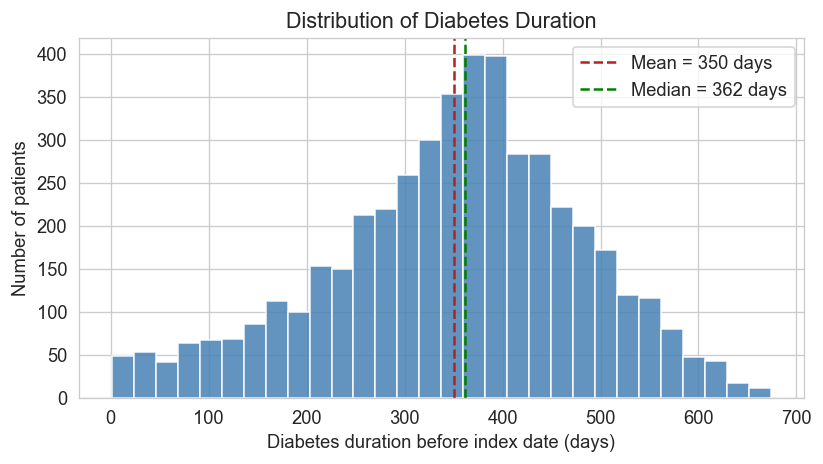

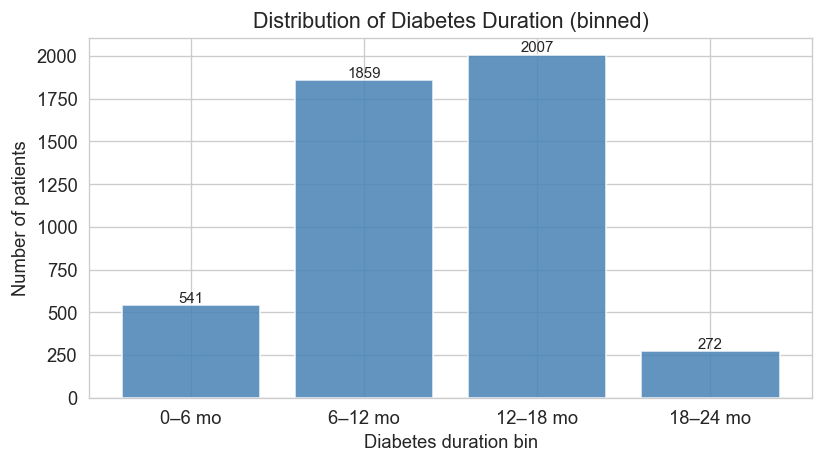

In [128]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(
    df["diabetes_duration_days"],
    bins=30,
    color="steelblue",
    edgecolor="white",
    alpha=0.85,
)
mean_val = df["diabetes_duration_days"].mean()
median_val = df["diabetes_duration_days"].median()
ax.axvline(
    mean_val,
    color="firebrick",
    linestyle="--",
    label=f"Mean = {mean_val:.0f} days",
)
ax.axvline(
    median_val,
    color="green",
    linestyle="--",
    label=f"Median = {median_val:.0f} days",
)
ax.set_xlabel("Diabetes duration before index date (days)")
ax.set_ylabel("Number of patients")
ax.set_title("Distribution of Diabetes Duration")
ax.legend()
plt.tight_layout()
plt.show()

# --- Bar chart of binned diabetes_duration categories ---
fig, ax = plt.subplots(figsize=(7, 4))
order = ["0–6 mo", "6–12 mo", "12–18 mo", "18–24 mo"]
counts = df["diabetes_duration"].value_counts().reindex(order)
bars = ax.bar(
    counts.index, counts.values, color="steelblue", edgecolor="white", alpha=0.85
)
for bar, n in zip(bars, counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(n)}",
        ha="center",
        va="bottom",
        fontsize=9,
    )
ax.set_xlabel("Diabetes duration bin")
ax.set_ylabel("Number of patients")
ax.set_title("Distribution of Diabetes Duration (binned)")
plt.tight_layout()
plt.show()


## Top Second-line Drugs

First second-line agent initiated after metformin:
---------------------------------------------
glyburide             n=1825  (39.0%)
glipizide             n=1444  (30.9%)
glimepiride           n=454  (9.7%)
rosiglitazone         n=404  (8.6%)
pioglitazone          n=324  (6.9%)
repaglinide           n= 80  (1.7%)
sitagliptin           n= 78  (1.7%)
nateglinide           n= 49  (1.0%)
insulin glargine      n= 15  (0.3%)
insulin detemir       n=  4  (0.1%)
saxagliptin           n=  2  (0.0%)
                      N=4679


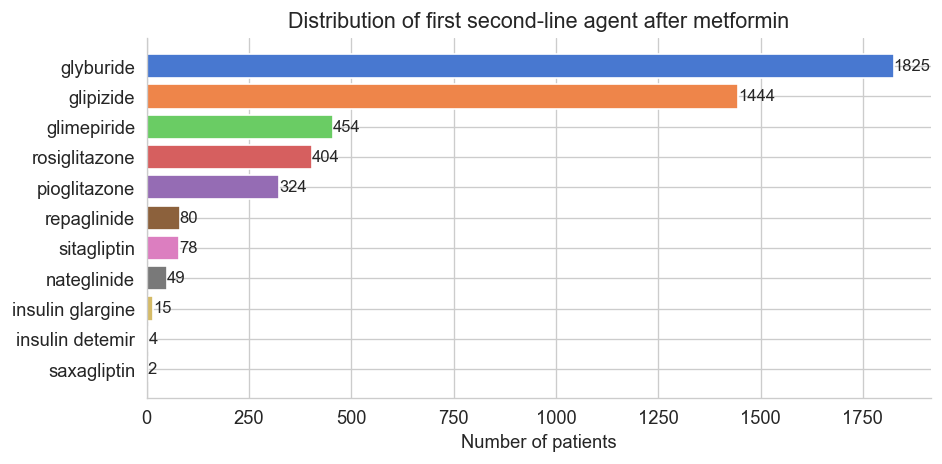

In [ ]:
drug_counts = df["second_line_drug_name"].value_counts()
drug_pcts = (drug_counts / len(df) * 100).round(1)

print("First second-line agent initiated after metformin:")
print("-" * 45)
for drug, n in drug_counts.items():
    print(f"{drug:<20s}  n={n:>3d}  ({drug_pcts[drug]:.1f}%)")
print(f"{'':20s}  N={drug_counts.sum():>3d}")

# Bar chart
fig, ax = plt.subplots(figsize=(8, 4))
colors = sns.color_palette("muted", len(drug_counts))
bars = ax.barh(
    drug_counts.index[::-1],
    drug_counts.values[::-1],
    color=colors[::-1],
    edgecolor="white",
)
ax.set_xlabel("Number of patients")
ax.set_title("Distribution of first second-line agent after metformin")
for bar, val in zip(bars, drug_counts.values[::-1]):
    ax.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        str(val),
        va="center",
        fontsize=10,
    )
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

## Comorbidity Co-occurrence

Comorbidity count distribution:
comorbidity_count
0     315
1     972
2    1629
3    1547
4     216
Name: count, dtype: int64

Comorbidity co-occurrence matrix (counts):
              hypertension  depression   chd   ckd
hypertension           467         309   435   313
depression             309        2527  2347  1671
chd                    435        2347  4058  2491
ckd                    313        1671  2491  2683


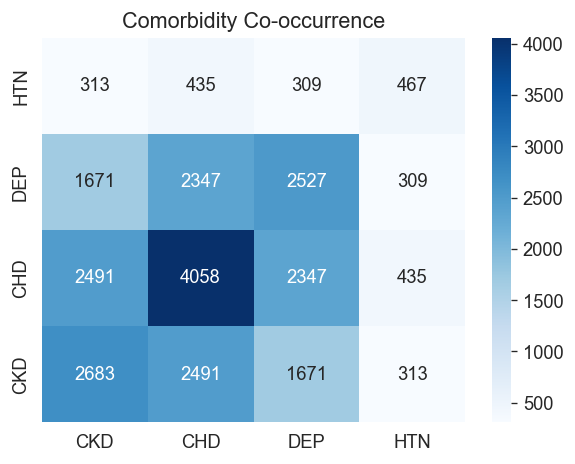

In [130]:
comorbidity_cols = ["hypertension", "depression", "chd", "ckd"]

# Comorbidity count distribution
df["comorbidity_count"] = df[comorbidity_cols].sum(axis=1)
print("Comorbidity count distribution:")
print(df["comorbidity_count"].value_counts().sort_index())
print()

# Co-occurrence matrix
co_matrix = pd.DataFrame(index=comorbidity_cols, columns=comorbidity_cols, dtype=float)
for c1 in comorbidity_cols:
    for c2 in comorbidity_cols:
        if c1 == c2:
            co_matrix.loc[c1, c2] = df[c1].sum()
        else:
            co_matrix.loc[c1, c2] = ((df[c1] == 1) & (df[c2] == 1)).sum()

print("Comorbidity co-occurrence matrix (counts):")
print(co_matrix.astype(int))

# Heatmap — x-axis reversed
x_order = comorbidity_cols[::-1]
co_matrix_flipped = co_matrix[x_order]

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    co_matrix_flipped.astype(int),
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=ax,
    xticklabels=["CKD", "CHD", "DEP", "HTN"],
    yticklabels=["HTN", "DEP", "CHD", "CKD"],
)
ax.set_title("Comorbidity Co-occurrence")
plt.tight_layout()
plt.show()

## Time to Escalation

### By Demographics

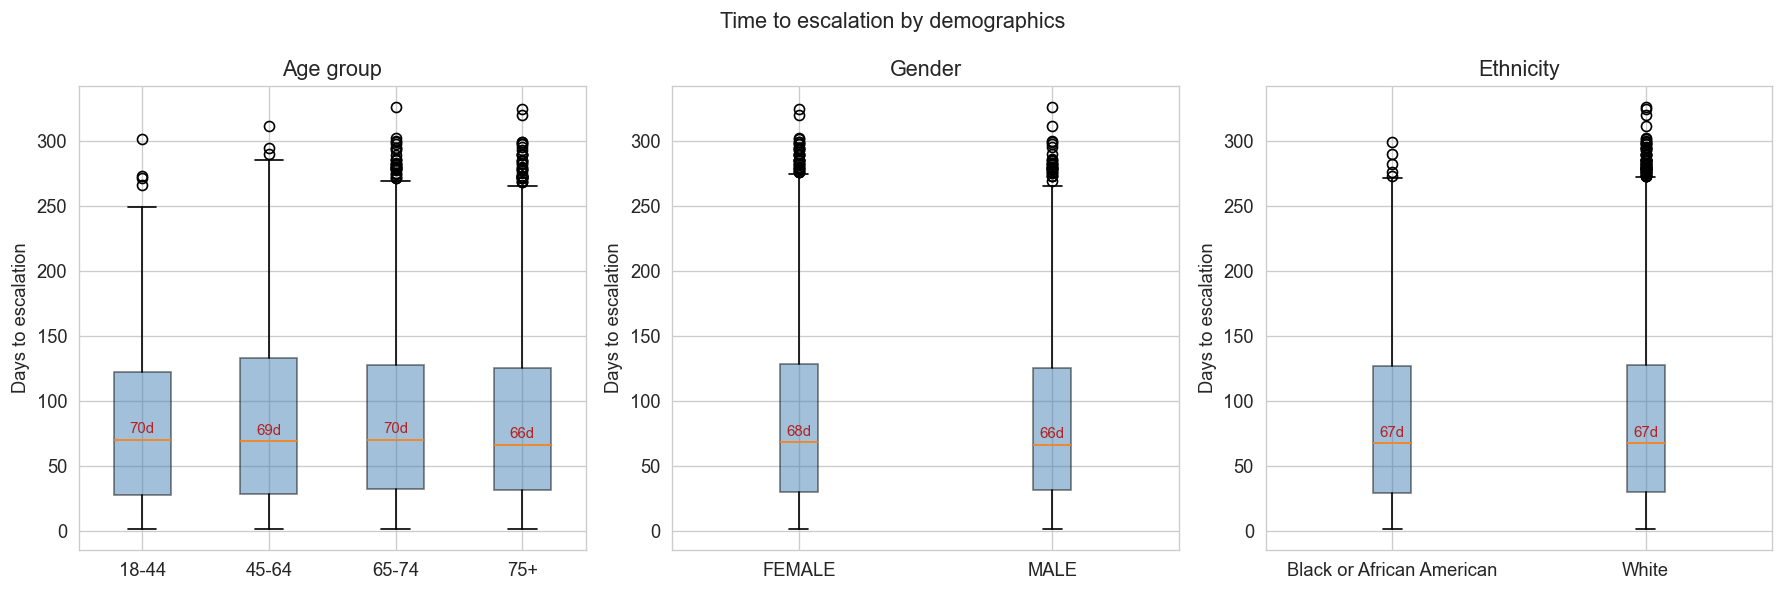

In [131]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (label, col) in zip(
    axes,
    [("Age group", "age_group"), ("Gender", "gender"), ("Ethnicity", "race")],
):
    grouped = df.groupby(col)["time_to_escalation"]
    keys = list(grouped.groups.keys())
    labels = [str(k) for k in keys]
    groups = [grouped.get_group(k).dropna().values for k in keys]
    ax.boxplot(
        groups,
        labels=labels,
        patch_artist=True,
        boxprops=dict(facecolor="steelblue", alpha=0.5),
    )
    ax.set_title(label)
    ax.set_ylabel("Days to escalation")
    ax.tick_params(axis="x")
    medians = grouped.median()
    for i, med in enumerate(medians.values):
        ax.text(
            i + 1,
            med + 5,
            f"{med:.0f}d",
            ha="center",
            fontsize=9,
            color="firebrick",
        )
plt.suptitle("Time to escalation by demographics", fontsize=13)
plt.tight_layout()
plt.show()

### By Comorbidities

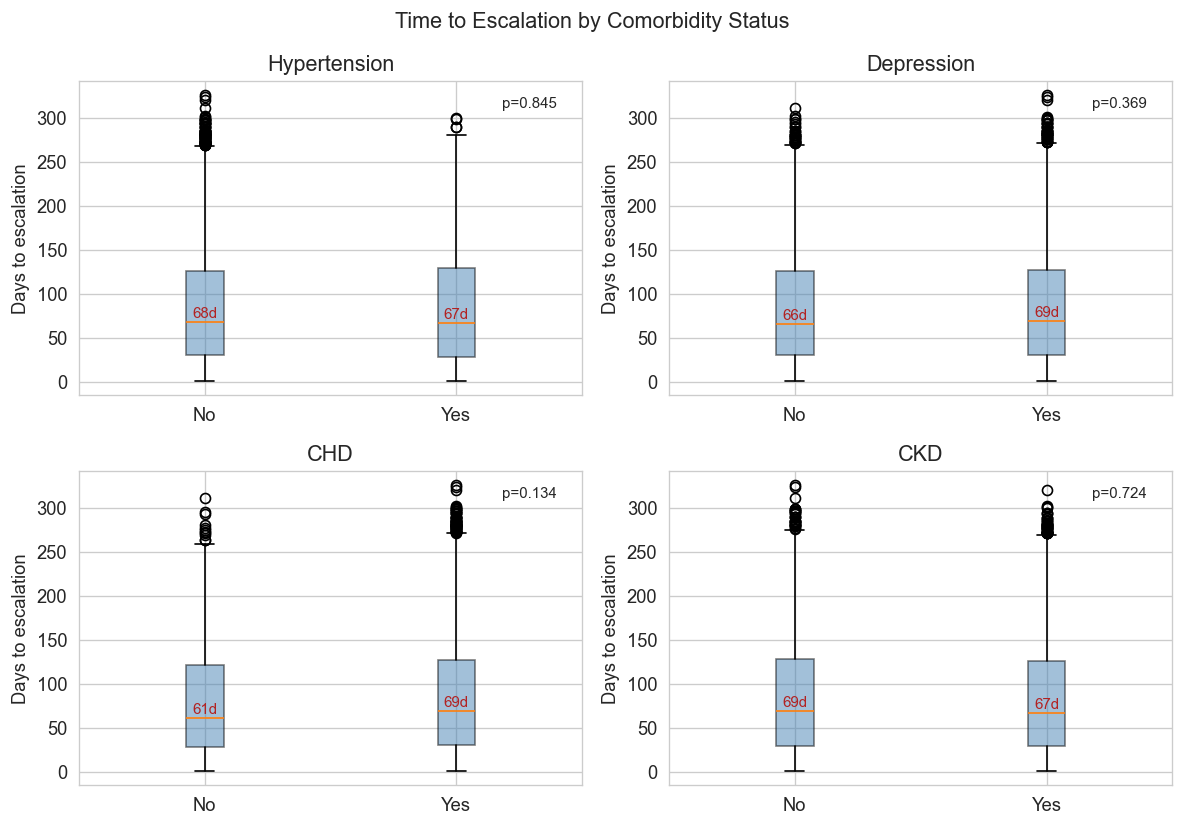

In [132]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for ax, (label, col) in zip(
    axes.ravel(),
    [
        ("Hypertension", "hypertension"),
        ("Depression", "depression"),
        ("CHD", "chd"),
        ("CKD", "ckd"),
    ],
):
    data_0 = df[df[col] == 0]["time_to_escalation"]
    data_1 = df[df[col] == 1]["time_to_escalation"]
    ax.boxplot(
        [data_0, data_1],
        labels=["No", "Yes"],
        patch_artist=True,
        boxprops=dict(facecolor="steelblue", alpha=0.5),
    )
    ax.set_title(label)
    ax.set_ylabel("Days to escalation")
    medians = df.groupby(col)["time_to_escalation"].median()
    for i, (grp, med) in enumerate(medians.items()):
        ax.text(
            i + 1, med + 5, f"{med:.0f}d", ha="center", fontsize=9, color="firebrick"
        )
    if len(data_0) > 0 and len(data_1) > 0:
        stat, p = stats.mannwhitneyu(data_0, data_1, alternative="two-sided")
        ax.text(
            0.95,
            0.95,
            f"p={p:.3f}",
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=9,
        )

plt.suptitle("Time to Escalation by Comorbidity Status", fontsize=13)
plt.tight_layout()
plt.show()

### By Diabetes Duration

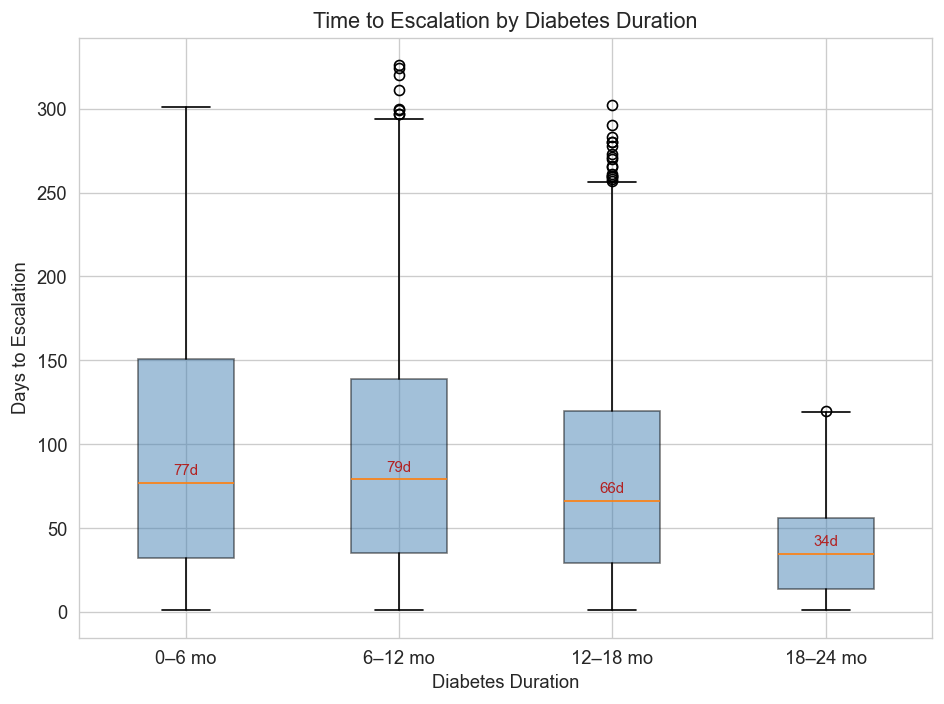

In [133]:
import pandas as pd
import matplotlib.pyplot as plt

# Dynamically get category order
if pd.api.types.is_categorical_dtype(df["diabetes_duration"]):
    order = list(df["diabetes_duration"].cat.categories)
else:
    order = df["diabetes_duration"].dropna().astype(str).unique().tolist()

# Keep only groups that actually have data
order = [grp for grp in order if (df["diabetes_duration"] == grp).any()]

fig, ax = plt.subplots(figsize=(8, 6))

grouped_data = [
    df.loc[df["diabetes_duration"] == grp, "time_to_escalation"].dropna()
    for grp in order
]

medians = {
    grp: df.loc[df["diabetes_duration"] == grp, "time_to_escalation"].median()
    for grp in order
}

ax.boxplot(
    grouped_data,
    labels=order,
    patch_artist=True,
    boxprops=dict(facecolor="steelblue", alpha=0.5),
)

ax.set_title("Time to Escalation by Diabetes Duration")
ax.set_ylabel("Days to Escalation")
ax.set_xlabel("Diabetes Duration")

for i, grp in enumerate(order, start=1):
    med = medians[grp]
    if pd.notna(med):
        ax.text(
            i,
            med + 5,
            f"{med:.0f}d",
            ha="center",
            fontsize=9,
            color="firebrick",
        )

plt.tight_layout()
plt.show()

## Second Line Therapy by Diabetes Duration

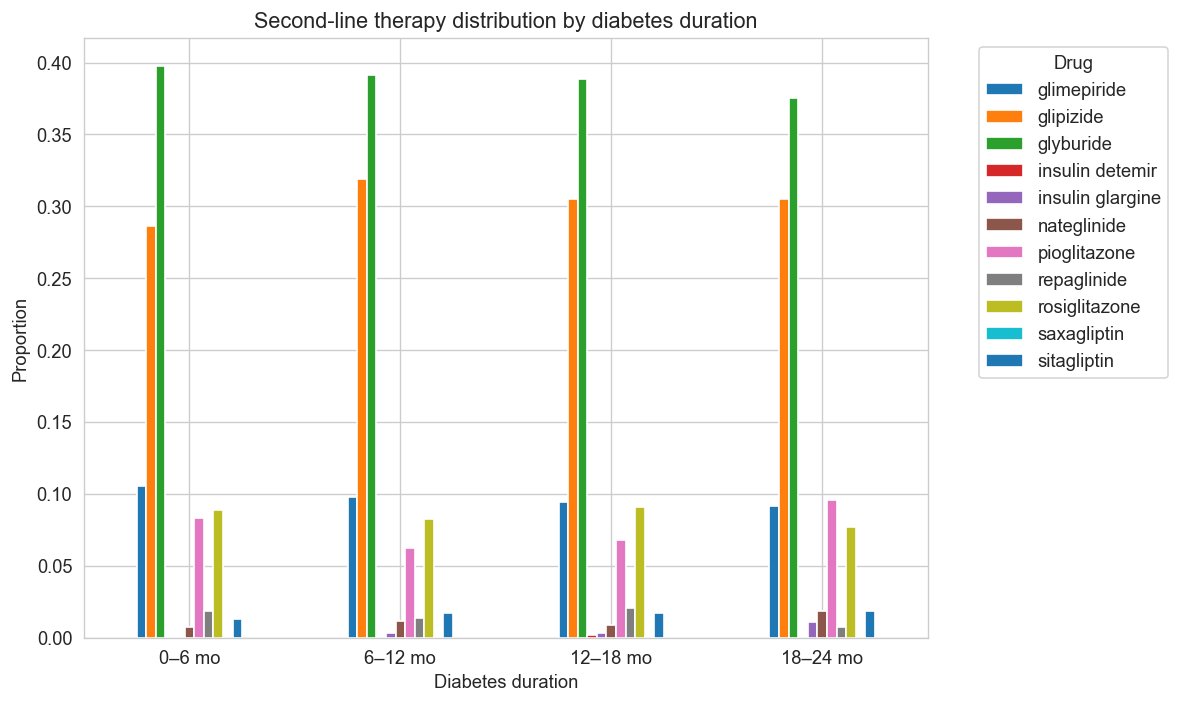

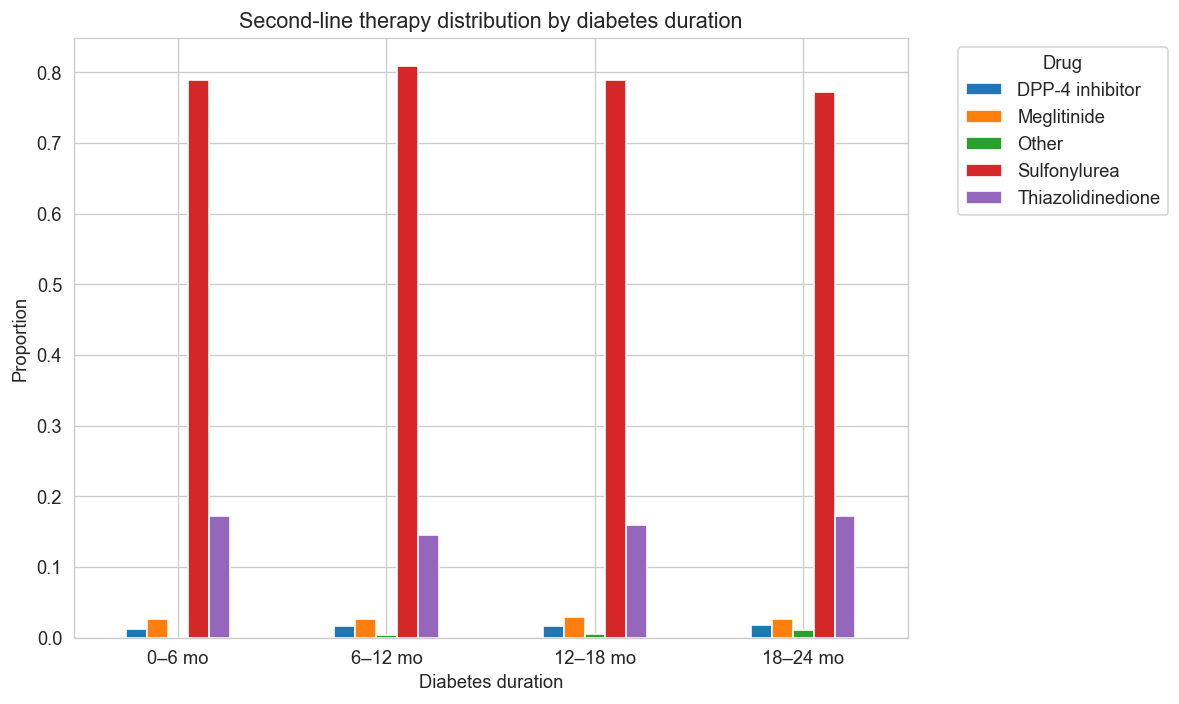

In [134]:
# Drug class mapping
drug_class_map = {
    "glyburide": "Sulfonylurea",
    "glipizide": "Sulfonylurea",
    "glimepiride": "Sulfonylurea",
    "pioglitazone": "Thiazolidinedione",
    "rosiglitazone": "Thiazolidinedione",
    "sitagliptin": "DPP-4 inhibitor",
    "nateglinide": "Meglitinide",
    "repaglinide": "Meglitinide",
}

# Map first drug to class
df["first_drug_class"] = df["second_line_drug_name"].map(drug_class_map).fillna("Other")

ct = pd.crosstab(
    df["diabetes_duration"], df["second_line_drug_name"], normalize="index"
)

ct.plot(kind="bar", figsize=(10, 6))
plt.xticks(rotation=0)
plt.title("Second-line therapy distribution by diabetes duration")
plt.ylabel("Proportion")
plt.xlabel("Diabetes duration")
plt.legend(title="Drug", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# -------------- by Class --------------

ct = pd.crosstab(df["diabetes_duration"], df["first_drug_class"], normalize="index")

ct.plot(kind="bar", figsize=(10, 6))
plt.xticks(rotation=0)
plt.title("Second-line therapy distribution by diabetes duration")
plt.ylabel("Proportion")
plt.xlabel("Diabetes duration")
plt.legend(title="Drug", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Step 3: Survival Analysis

## Kaplan-Meier Curves

### Overall Curve

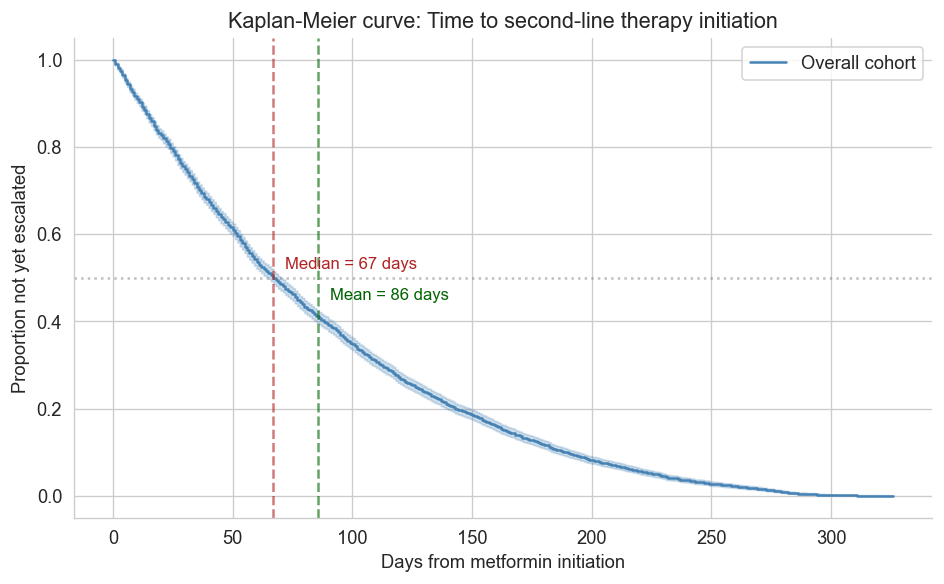

Median time to escalation: 67 days
Mean time to escalation: 85.9 days


In [ ]:
kmf = KaplanMeierFitter()

fig, ax = plt.subplots(figsize=(8, 5))

kmf.fit(df["time_to_escalation"], event_observed=df["event"], label="Overall cohort")
kmf.plot_survival_function(ax=ax, ci_show=True, color="steelblue")

ax.set_xlabel("Days from metformin initiation")
ax.set_ylabel("Proportion not yet escalated")
ax.set_title("Kaplan-Meier curve: Time to second-line therapy initiation")

# 50% survival reference line
ax.axhline(y=0.5, color="gray", linestyle=":", alpha=0.5)

# Median line
median_surv = kmf.median_survival_time_
ax.axvline(x=median_surv, color="firebrick", linestyle="--", alpha=0.6)
ax.text(
    median_surv + 5,
    0.52,
    f"Median = {median_surv:.0f} days",
    color="firebrick",
    fontsize=10,
)

# Mean line
mean_surv = df["time_to_escalation"].mean()
ax.axvline(x=mean_surv, color="darkgreen", linestyle="--", alpha=0.6)
ax.text(
    mean_surv + 5,
    0.45,
    f"Mean = {mean_surv:.0f} days",
    color="darkgreen",
    fontsize=10,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

print(f"Median time to escalation: {median_surv:.0f} days")
print(f"Mean time to escalation: {mean_surv:.1f} days")

### Stratified KM Curve

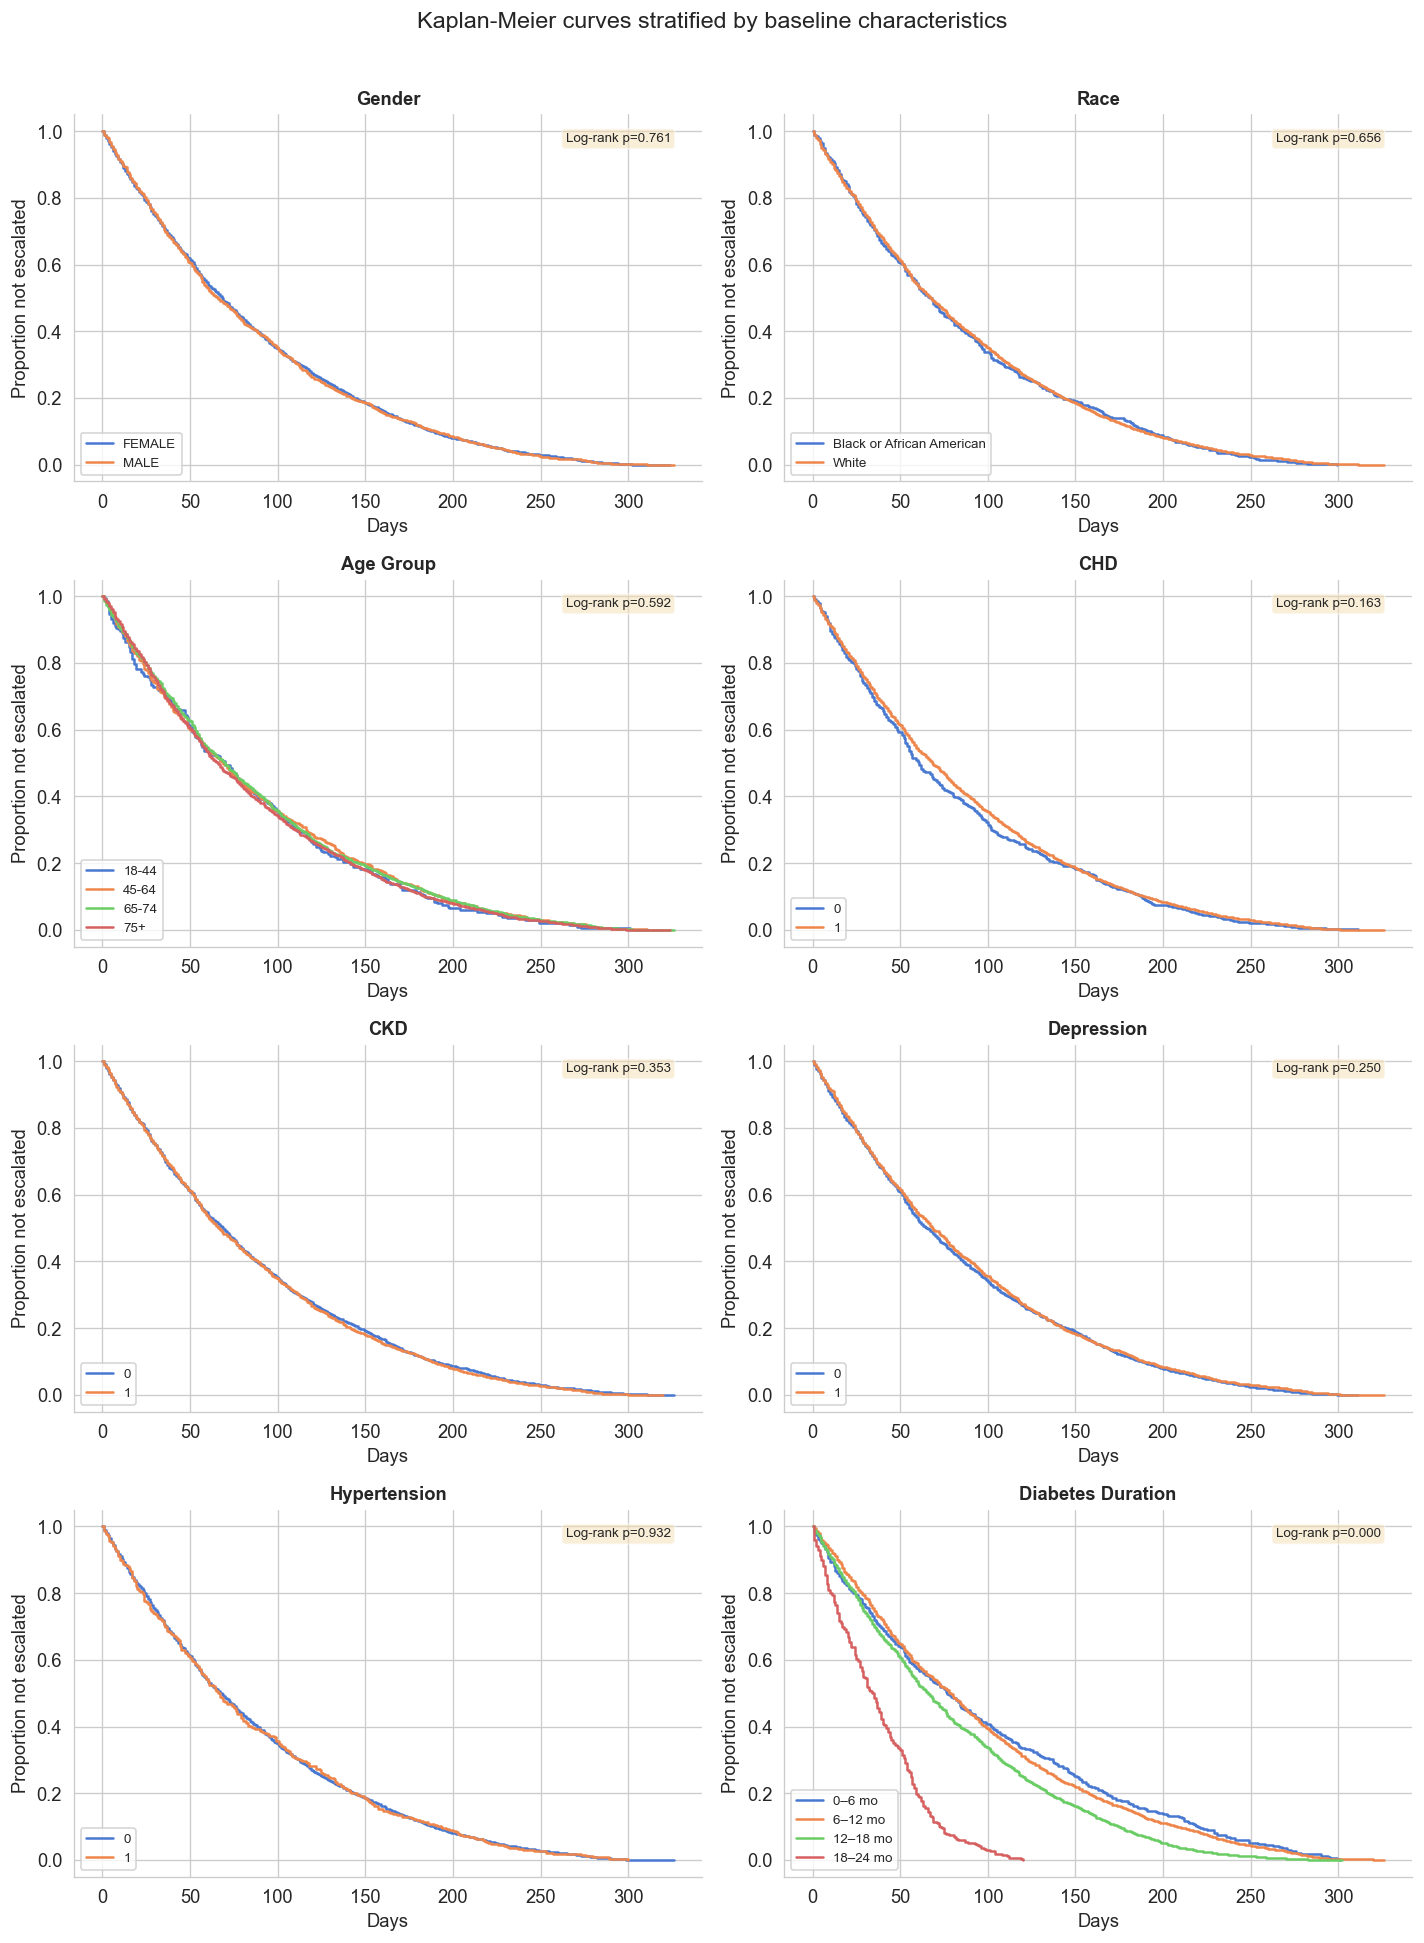

In [136]:
strat_vars = {
    "Gender": "gender",
    "Race": "race",
    "Age Group": "age_group",
    "CHD": "chd",
    "CKD": "ckd",
    "Depression": "depression",
    "Hypertension": "hypertension",
    "Diabetes Duration": "diabetes_duration",
}

fig, axes = plt.subplots(4, 2, figsize=(12, 16))
axes = axes.ravel()

kmf = KaplanMeierFitter()

for idx, (title, col) in enumerate(strat_vars.items()):
    ax = axes[idx]

    if col == "diabetes_duration":
        order = ["0–6 mo", "6–12 mo", "12–18 mo", "18–24 mo"]
        df[col] = pd.Categorical(df[col], categories=order, ordered=True)
        groups = [g for g in order if g in df[col].dropna().unique()]
    else:
        groups = df[col].dropna().unique()
        groups = sorted(groups, key=lambda x: str(x))

    palette = sns.color_palette("muted", len(groups))

    for i, grp in enumerate(groups):
        mask = df[col] == grp
        if mask.sum() < 2:
            continue
        kmf.fit(
            df.loc[mask, "time_to_escalation"],
            event_observed=df.loc[mask, "event"],
            label=str(grp),
        )
        kmf.plot_survival_function(ax=ax, ci_show=False, color=palette[i])

    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("Days")
    ax.set_ylabel("Proportion not escalated")
    ax.legend(fontsize=8, loc="lower left")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    valid_groups = [g for g in groups if (df[col] == g).sum() >= 2]
    if len(valid_groups) >= 2:
        try:
            result = multivariate_logrank_test(
                df.loc[df[col].isin(valid_groups), "time_to_escalation"],
                df.loc[df[col].isin(valid_groups), col],
                df.loc[df[col].isin(valid_groups), "event"],
            )
            p = result.p_value
            ax.text(
                0.95,
                0.95,
                f"Log-rank p={p:.3f}",
                transform=ax.transAxes,
                ha="right",
                va="top",
                fontsize=8,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="wheat", alpha=0.5),
            )
        except Exception:
            pass

# Hide unused axes
for idx in range(len(strat_vars), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle(
    "Kaplan-Meier curves stratified by baseline characteristics",
    fontsize=14,
    y=1.01,
)
plt.tight_layout()
plt.show()

### By Drug Class

First second-line agent by drug class:
----------------------------------------
  Sulfonylurea               n=3723  (79.6%)
  Thiazolidinedione          n=728  (15.6%)
  Meglitinide                n=129  (2.8%)
  DPP-4 inhibitor            n= 78  (1.7%)
  Other                      n= 21  (0.4%)


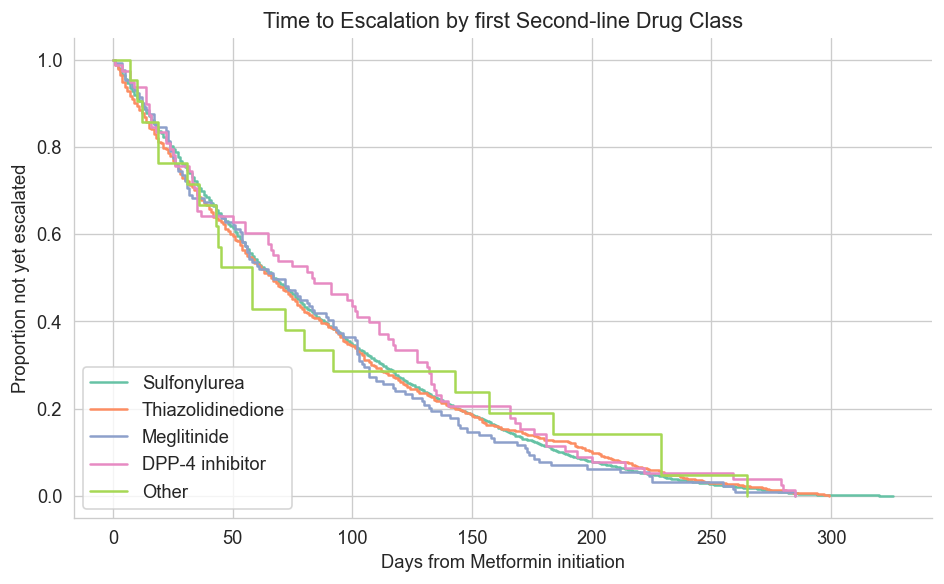

In [170]:
# Drug class mapping
drug_class_map = {
    "glyburide": "Sulfonylurea",
    "glipizide": "Sulfonylurea",
    "glimepiride": "Sulfonylurea",
    "pioglitazone": "Thiazolidinedione",
    "rosiglitazone": "Thiazolidinedione",
    "sitagliptin": "DPP-4 inhibitor",
    "nateglinide": "Meglitinide",
    "repaglinide": "Meglitinide",
}

# Map first drug to class
df["first_drug_class"] = df["second_line_drug_name"].map(drug_class_map).fillna("Other")

# Class distribution
class_counts = df["first_drug_class"].value_counts()
print("First second-line agent by drug class:")
print("-" * 40)
for cls, n in class_counts.items():
    print(f"  {cls:<25s}  n={n:>3d}  ({n / len(df) * 100:.1f}%)")

# KM by drug class
fig, ax = plt.subplots(figsize=(8, 5))
kmf = KaplanMeierFitter()
palette = sns.color_palette("Set2", len(class_counts))

for i, cls in enumerate(class_counts.index):
    mask = df["first_drug_class"] == cls
    if mask.sum() >= 2:
        kmf.fit(
            df.loc[mask, "time_to_escalation"],
            event_observed=df.loc[mask, "event"],
            label=cls,
        )
        kmf.plot_survival_function(ax=ax, ci_show=False, color=palette[i])

ax.set_xlabel("Days from Metformin initiation")
ax.set_ylabel("Proportion not yet escalated")
ax.set_title("Time to Escalation by first Second-line Drug Class")
ax.legend(loc="lower left")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

## Cox Proportional Hazards Model

### Model Fitting

In [146]:
# Prepare data for Cox regression
cox_df = df[
    [
        "time_to_escalation",
        "event",
        "age_at_index",
        "gender",
        "race",
        "chd",
        "ckd",
        "depression",
        "hypertension",
        "diabetes_duration",
    ]
].copy()

# Encode gender: FEMALE = 0, MALE = 1
cox_df["male"] = (cox_df["gender"] == "MALE").astype(int)

# Encode race: dummies with White as reference
race_dummies = pd.get_dummies(cox_df["race"], prefix="race", drop_first=False)
if "race_White" in race_dummies.columns:
    race_dummies = race_dummies.drop(columns=["race_White"])
else:
    race_dummies = race_dummies.iloc[:, 1:]  # fallback: drop first column

# Encode diabetes duration: dummies with 0–3 mo as reference
cox_df["diabetes_duration"] = pd.Categorical(
    cox_df["diabetes_duration"],
    categories=["0–6 mo", "6–12 mo", "12–18 mo", "18–24 mo"],
    ordered=True,
)

duration_dummies = pd.get_dummies(
    cox_df["diabetes_duration"],
    prefix="diabetes_duration",
    drop_first=False,
)

if "diabetes_duration_0–6 mo" in duration_dummies.columns:
    duration_dummies = duration_dummies.drop(columns=["diabetes_duration_0–6 mo"])
else:
    duration_dummies = duration_dummies.iloc[:, 1:]  # fallback: drop first column

# Combine all predictors
cox_df = pd.concat([cox_df, race_dummies, duration_dummies], axis=1)

# Drop original categorical columns
cox_df = cox_df.drop(columns=["gender", "race", "diabetes_duration"])

# Rename for readability
cox_df.columns = [
    c.replace("race_", "race: ").replace("diabetes_duration_", "diabetes duration: ")
    for c in cox_df.columns
]

print("Cox model input shape:", cox_df.shape)
print("\nVariable summary:")
cox_df.describe()

# ============= Fit Cox PH model =============
cph = CoxPHFitter()
cph.fit(cox_df, duration_col="time_to_escalation", event_col="event")

print("\n" + "=" * 70)
print("COX PROPORTIONAL HAZARDS MODEL — RESULTS")
print("=" * 70)
cph.print_summary(
    columns=[
        "coef",
        "exp(coef)",
        "se(coef)",
        "p",
        "exp(coef) lower 95%",
        "exp(coef) upper 95%",
    ]
)

Cox model input shape: (4679, 12)

Variable summary:

COX PROPORTIONAL HAZARDS MODEL — RESULTS


<lifelines.CoxPHFitter: fitted with 4679 total observations, 0 right-censored observations>
             duration col = 'time_to_escalation'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 4679
number of events observed = 4679
   partial log-likelihood = -34725.85
         time fit was run = 2026-04-24 17:58:47 UTC

---
                                 coef exp(coef)  se(coef) exp(coef) lower 95% exp(coef) upper 95%      p
covariate                                                                                               
age_at_index                     0.00      1.00      0.00                1.00                1.00   0.41
chd                             -0.11      0.90      0.05                0.82                0.98   0.02
ckd                              0.01      1.01      0.03                0.95                1.07   0.83
depression                      -0.05      0.95      0.03                0.90                1.01   0.10
hypertension                    -0.01      0.99      0.05                0.90                1.09   0.78
male                             0.01      1.01      0.03                0.95                1.07   0.72
race: Black or African American  0.02      1.02      0.04                0.94                1.11   0.64
diabetes duration: 6–12 mo       0.06      1.07      0.05                0.97                1.17   0.20
diabetes duration: 12–18 mo      0.30      1.36      0.05                1.23                1.49 <0.005
diabetes duration: 18–24 mo      1.24      3.46      0.08                2.98                4.03 <0.005
---
Concordance = 0.55
Partial AIC = 69471.70
log-likelihood ratio test = 283.55 on 10 df
-log2(p) of ll-ratio test = 180.49

### Plotting Hazard Ratios

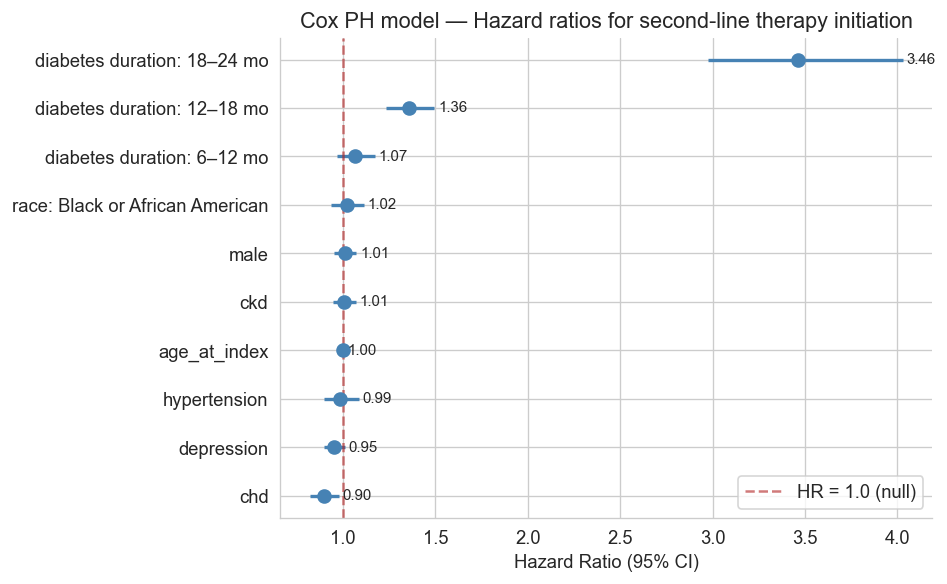

In [147]:
# Forest plot of hazard ratios
fig, ax = plt.subplots(figsize=(8, 5))

summary = cph.summary[
    ["exp(coef)", "exp(coef) lower 95%", "exp(coef) upper 95%"]
].copy()
summary = summary.sort_values("exp(coef)")

y_pos = range(len(summary))
ax.hlines(
    y_pos,
    summary["exp(coef) lower 95%"],
    summary["exp(coef) upper 95%"],
    color="steelblue",
    linewidth=2,
)
ax.scatter(summary["exp(coef)"], y_pos, color="steelblue", s=60, zorder=3)
ax.axvline(x=1.0, color="firebrick", linestyle="--", alpha=0.6, label="HR = 1.0 (null)")

ax.set_yticks(list(y_pos))
ax.set_yticklabels(summary.index)
ax.set_xlabel("Hazard Ratio (95% CI)")
ax.set_title("Cox PH model — Hazard ratios for second-line therapy initiation")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(loc="lower right")

# Add HR labels
for i, (idx, row) in enumerate(summary.iterrows()):
    ax.text(
        row["exp(coef) upper 95%"] + 0.02,
        i,
        f"{row['exp(coef)']:.2f}",
        va="center",
        fontsize=9,
    )

plt.tight_layout()
plt.show()

### Stratified Models

#### By Diabetes Duration

In [150]:
def run_stratified_cox(df, strat_col, strat_label, covariate_cols):
    """
    Run Cox PH model within each stratum of strat_col.
    Returns a summary DataFrame of HRs across strata.
    """
    results = []

    # Keep diabetes_duration ordered if that's the stratifier
    if strat_col == "diabetes_duration":
        strata = ["0–6 mo", "6–12 mo", "12–18 mo", "18–24 mo"]
        strata = [s for s in strata if s in df[strat_col].dropna().unique()]
    else:
        strata = sorted(df[strat_col].dropna().unique(), key=lambda x: str(x))

    for stratum in strata:
        subset = df[df[strat_col] == stratum].copy()

        if len(subset) < 10:
            print(f"  Skipping {strat_label}={stratum}: n={len(subset)} (too few)")
            continue

        # Select covariates that exist and vary within this subset
        valid_covs = []
        for c in covariate_cols:
            if c in subset.columns and subset[c].nunique() > 1:
                valid_covs.append(c)

        if len(valid_covs) == 0:
            print(
                f"  Skipping {strat_label}={stratum}: no valid covariates with variance"
            )
            continue

        model_df = subset[["time_to_escalation", "event"] + valid_covs].dropna()

        if len(model_df) < 10:
            print(f"  Skipping {strat_label}={stratum}: n={len(model_df)} after dropna")
            continue

        try:
            cph_s = CoxPHFitter(penalizer=0.1)
            cph_s.fit(model_df, duration_col="time_to_escalation", event_col="event")

            for cov in valid_covs:
                hr = cph_s.hazard_ratios_[cov]
                ci_low = np.exp(cph_s.confidence_intervals_.loc[cov].iloc[0])
                ci_high = np.exp(cph_s.confidence_intervals_.loc[cov].iloc[1])
                p = cph_s.summary.loc[cov, "p"]

                results.append(
                    {
                        "Stratum": f"{strat_label}={stratum}",
                        "N": len(model_df),
                        "Covariate": cov,
                        "HR": hr,
                        "CI_low": ci_low,
                        "CI_high": ci_high,
                        "p": p,
                    }
                )
        except Exception as e:
            print(f"  {strat_label}={stratum}: model failed ({e})")

    return pd.DataFrame(results)


# Prepare diabetes duration dummies first
df["diabetes_duration"] = pd.Categorical(
    df["diabetes_duration"],
    categories=["0–6 mo", "6–12 mo", "12–18 mo", "18–24 mo"],
    ordered=True,
)

duration_dummies = pd.get_dummies(
    df["diabetes_duration"],
    prefix="diabetes_duration",
    drop_first=False,
)

if "diabetes_duration_0–6 mo" in duration_dummies.columns:
    duration_dummies = duration_dummies.drop(columns=["diabetes_duration_0–6 mo"])
else:
    duration_dummies = duration_dummies.iloc[:, 1:]

df = pd.concat([df, duration_dummies], axis=1)

# Prepare male variable in df if not already
df["male"] = (df["gender"] == "MALE").astype(int)

# Core covariates for stratified models
base_covs = [
    "age_at_index",
    "male",
    "chd",
    "ckd",
    "depression",
    "hypertension",
    "diabetes_duration_0–6 mo",
    "diabetes_duration_6–12 mo",
    "diabetes_duration_12–18 mo",
    "diabetes_duration_18–24 mo",
]

results = run_stratified_cox(
    df=df,
    strat_col="diabetes_duration",
    strat_label="Diabetes duration",
    covariate_cols=[
        "age_at_index",
        "male",
        "chd",
        "ckd",
        "depression",
        "hypertension",
    ],  # don't include diabetes_duration dummies here
)

display(results)

,Stratum,N,Covariate,HR,CI_low,CI_high,p
0,Diabetes duration=0–6 mo,541,age_at_index,1.001175,0.995482,1.006900,0.686565
1,Diabetes duration=0–6 mo,541,male,0.985420,0.832991,1.165741,0.863981
2,Diabetes duration=0–6 mo,541,chd,0.921396,0.756314,1.122511,0.416393
3,Diabetes duration=0–6 mo,541,ckd,0.940165,0.789892,1.119027,0.487457
4,Diabetes duration=0–6 mo,541,depression,0.918599,0.775488,1.088121,0.325802
5,Diabetes duration=0–6 mo,541,hypertension,0.933374,0.671246,1.297867,0.681867
6,Diabetes duration=6–12 mo,1859,age_at_index,0.998834,0.995583,1.002096,0.483018
7,Diabetes duration=6–12 mo,1859,male,1.011356,0.923389,1.107702,0.807842
8,Diabetes duration=6–12 mo,1859,chd,0.970256,0.850464,1.106922,0.653362
9,Diabetes duration=6–12 mo,1859,ckd,1.050335,0.960534,1.148530,0.281504


#### By Gender

In [151]:
# Stratify by gender
print("\n--- Stratified by Gender ---")
df = df.loc[:, ~df.columns.duplicated()].copy()
gender_results = run_stratified_cox(
    df,
    "gender",
    "Gender",
    [
        "age_at_index",
        "chd",
        "ckd",
        "depression",
        "hypertension",
        "diabetes_duration_0–6 mo",
        "diabetes_duration_6–12 mo",
        "diabetes_duration_12–18 mo",
        "diabetes_duration_18–24 mo",
    ],
)

if len(gender_results) > 0:
    print(gender_results.to_string(index=False, float_format="%.3f"))


--- Stratified by Gender ---
      Stratum    N                  Covariate    HR  CI_low  CI_high     p
Gender=FEMALE 2906               age_at_index 1.001   0.999    1.004 0.352
Gender=FEMALE 2906                        chd 0.945   0.850    1.051 0.298
Gender=FEMALE 2906                        ckd 1.035   0.962    1.113 0.356
Gender=FEMALE 2906                 depression 0.919   0.856    0.988 0.021
Gender=FEMALE 2906               hypertension 0.964   0.858    1.084 0.541
Gender=FEMALE 2906  diabetes_duration_6–12 mo 0.965   0.875    1.065 0.479
Gender=FEMALE 2906 diabetes_duration_12–18 mo 1.210   1.096    1.337 0.000
Gender=FEMALE 2906 diabetes_duration_18–24 mo 2.867   2.417    3.402 0.000
  Gender=MALE 1773               age_at_index 1.000   0.997    1.003 0.951
  Gender=MALE 1773                        chd 0.861   0.752    0.986 0.031
  Gender=MALE 1773                        ckd 0.971   0.884    1.065 0.531
  Gender=MALE 1773                 depression 1.025   0.934    1.124 0

#### By Age Group

In [152]:
# Stratify by age group
print("\n--- Stratified by Age Group ---")
age_results = run_stratified_cox(
    df,
    "age_group",
    "Age",
    [
        "male",
        "chd",
        "ckd",
        "depression",
        "hypertension",
        "diabetes_duration_0–6 mo",
        "diabetes_duration_6–12 mo",
        "diabetes_duration_12–18 mo",
        "diabetes_duration_18–24 mo",
    ],
)
if len(age_results) > 0:
    print(age_results.to_string(index=False, float_format="%.3f"))


--- Stratified by Age Group ---
  Stratum    N                  Covariate    HR  CI_low  CI_high     p
Age=18-44  202                       male 1.058   0.802    1.396 0.690
Age=18-44  202                        chd 0.941   0.637    1.390 0.759
Age=18-44  202                        ckd 0.800   0.593    1.080 0.146
Age=18-44  202                 depression 0.644   0.481    0.864 0.003
Age=18-44  202               hypertension 0.920   0.591    1.431 0.711
Age=18-44  202  diabetes_duration_6–12 mo 1.046   0.718    1.524 0.816
Age=18-44  202 diabetes_duration_12–18 mo 1.211   0.837    1.753 0.310
Age=18-44  202 diabetes_duration_18–24 mo 4.044   1.959    8.349 0.000
Age=45-64  738                       male 0.997   0.867    1.146 0.966
Age=45-64  738                        chd 0.927   0.757    1.135 0.464
Age=45-64  738                        ckd 1.021   0.883    1.180 0.783
Age=45-64  738                 depression 0.986   0.853    1.139 0.843
Age=45-64  738               hypertension 1.

#### By CHD

In [154]:
# Stratify by CHD
print("\n--- Stratified by CHD ---")
chd_results = run_stratified_cox(
    df,
    "chd",
    "CHD",
    [
        "age_at_index",
        "male",
        "ckd",
        "depression",
        "hypertension",
        "diabetes_duration_0–6 mo",
        "diabetes_duration_6–12 mo",
        "diabetes_duration_12–18 mo",
        "diabetes_duration_18–24 mo",
    ],
)
if len(chd_results) > 0:
    print(chd_results.to_string(index=False, float_format="%.3f"))


--- Stratified by CHD ---
Stratum    N                  Covariate    HR  CI_low  CI_high     p
  CHD=0  621               age_at_index 0.998   0.993    1.004 0.589
  CHD=0  621                       male 1.067   0.912    1.248 0.419
  CHD=0  621                        ckd 1.007   0.851    1.190 0.939
  CHD=0  621                 depression 0.988   0.834    1.171 0.891
  CHD=0  621               hypertension 0.900   0.641    1.265 0.544
  CHD=0  621  diabetes_duration_6–12 mo 0.944   0.779    1.143 0.553
  CHD=0  621 diabetes_duration_12–18 mo 1.311   1.077    1.597 0.007
  CHD=0  621 diabetes_duration_18–24 mo 3.092   1.863    5.133 0.000
  CHD=1 4058               age_at_index 1.001   0.999    1.003 0.297
  CHD=1 4058                       male 1.001   0.942    1.064 0.971
  CHD=1 4058                        ckd 1.012   0.952    1.076 0.694
  CHD=1 4058                 depression 0.954   0.899    1.014 0.129
  CHD=1 4058               hypertension 1.001   0.910    1.100 0.989
  CHD=1

#### By CKD

In [155]:
# Stratify by CKD
print("\n--- Stratified by CKD ---")
ckd_results = run_stratified_cox(
    df,
    "ckd",
    "CHD",
    [
        "age_at_index",
        "male",
        "ckd",
        "depression",
        "hypertension",
        "diabetes_duration_0–6 mo",
        "diabetes_duration_6–12 mo",
        "diabetes_duration_12–18 mo",
        "diabetes_duration_18–24 mo",
    ],
)
if len(chd_results) > 0:
    print(chd_results.to_string(index=False, float_format="%.3f"))


--- Stratified by CKD ---
Stratum    N                  Covariate    HR  CI_low  CI_high     p
  CHD=0  621               age_at_index 0.998   0.993    1.004 0.589
  CHD=0  621                       male 1.067   0.912    1.248 0.419
  CHD=0  621                        ckd 1.007   0.851    1.190 0.939
  CHD=0  621                 depression 0.988   0.834    1.171 0.891
  CHD=0  621               hypertension 0.900   0.641    1.265 0.544
  CHD=0  621  diabetes_duration_6–12 mo 0.944   0.779    1.143 0.553
  CHD=0  621 diabetes_duration_12–18 mo 1.311   1.077    1.597 0.007
  CHD=0  621 diabetes_duration_18–24 mo 3.092   1.863    5.133 0.000
  CHD=1 4058               age_at_index 1.001   0.999    1.003 0.297
  CHD=1 4058                       male 1.001   0.942    1.064 0.971
  CHD=1 4058                        ckd 1.012   0.952    1.076 0.694
  CHD=1 4058                 depression 0.954   0.899    1.014 0.129
  CHD=1 4058               hypertension 1.001   0.910    1.100 0.989
  CHD=1

#### By Depression

In [156]:
# Stratify by Depression
print("\n--- Stratified by Depression ---")
dep_results = run_stratified_cox(
    df,
    "depression",
    "Depression",
    [
        "age_at_index",
        "male",
        "chd",
        "ckd",
        "hypertension",
        "diabetes_duration_0–6 mo",
        "diabetes_duration_6–12 mo",
        "diabetes_duration_12–18 mo",
        "diabetes_duration_18–24 mo",
    ],
)
if len(dep_results) > 0:
    print(dep_results.to_string(index=False, float_format="%.3f"))


--- Stratified by Depression ---
     Stratum    N                  Covariate    HR  CI_low  CI_high     p
Depression=0 2152               age_at_index 0.999   0.996    1.002 0.617
Depression=0 2152                       male 0.957   0.880    1.041 0.307
Depression=0 2152                        chd 0.931   0.840    1.032 0.175
Depression=0 2152                        ckd 1.006   0.926    1.094 0.882
Depression=0 2152               hypertension 0.936   0.802    1.093 0.404
Depression=0 2152  diabetes_duration_6–12 mo 0.975   0.872    1.091 0.661
Depression=0 2152 diabetes_duration_12–18 mo 1.176   1.050    1.317 0.005
Depression=0 2152 diabetes_duration_18–24 mo 3.247   2.607    4.043 0.000
Depression=1 2527               age_at_index 1.002   0.999    1.004 0.188
Depression=1 2527                       male 1.051   0.973    1.135 0.209
Depression=1 2527                        chd 0.891   0.769    1.031 0.122
Depression=1 2527                        ckd 1.014   0.936    1.098 0.731
Depr

#### By Hypertension

In [157]:
# Stratify by Hypertension
print("\n--- Stratified by Hypertension ---")
htn_results = run_stratified_cox(
    df,
    "hypertension",
    "Hypertension",
    [
        "age_at_index",
        "male",
        "chd",
        "ckd",
        "depression",
        "diabetes_duration_0–6 mo",
        "diabetes_duration_6–12 mo",
        "diabetes_duration_12–18 mo",
        "diabetes_duration_18–24 mo",
    ],
)
if len(htn_results) > 0:
    print(htn_results.to_string(index=False, float_format="%.3f"))


--- Stratified by Hypertension ---
       Stratum    N                  Covariate    HR  CI_low  CI_high     p
Hypertension=0 4212               age_at_index 1.001   0.999    1.003 0.418
Hypertension=0 4212                       male 1.002   0.944    1.064 0.942
Hypertension=0 4212                        chd 0.912   0.837    0.995 0.038
Hypertension=0 4212                        ckd 1.007   0.948    1.069 0.825
Hypertension=0 4212                 depression 0.951   0.896    1.009 0.096
Hypertension=0 4212  diabetes_duration_6–12 mo 0.983   0.906    1.067 0.677
Hypertension=0 4212 diabetes_duration_12–18 mo 1.216   1.120    1.320 0.000
Hypertension=0 4212 diabetes_duration_18–24 mo 2.861   2.468    3.316 0.000
Hypertension=1  467               age_at_index 1.000   0.993    1.006 0.903
Hypertension=1  467                       male 1.076   0.896    1.291 0.432
Hypertension=1  467                        chd 0.976   0.689    1.383 0.892
Hypertension=1  467                        ckd 1.063

#### By Ethnicity

In [158]:
# Stratify by Hypertension
print("\n--- Stratified by Ethnicity ---")
htn_results = run_stratified_cox(
    df,
    "ethnicity",
    "Ethnicity",
    [
        "age_at_index",
        "male",
        "chd",
        "ckd",
        "depression",
        "diabetes_duration_0–6 mo",
        "diabetes_duration_6–12 mo",
        "diabetes_duration_12–18 mo",
        "diabetes_duration_18–24 mo",
    ],
)
if len(htn_results) > 0:
    print(htn_results.to_string(index=False, float_format="%.3f"))


--- Stratified by Ethnicity ---
                         Stratum    N                  Covariate    HR  CI_low  CI_high     p
Ethnicity=Not Hispanic or Latino 4679               age_at_index 1.001   0.999    1.003 0.469
Ethnicity=Not Hispanic or Latino 4679                       male 1.009   0.953    1.068 0.756
Ethnicity=Not Hispanic or Latino 4679                        chd 0.915   0.841    0.995 0.037
Ethnicity=Not Hispanic or Latino 4679                        ckd 1.012   0.955    1.071 0.695
Ethnicity=Not Hispanic or Latino 4679                 depression 0.957   0.904    1.012 0.123
Ethnicity=Not Hispanic or Latino 4679  diabetes_duration_6–12 mo 0.977   0.904    1.057 0.566
Ethnicity=Not Hispanic or Latino 4679 diabetes_duration_12–18 mo 1.223   1.131    1.323 0.000
Ethnicity=Not Hispanic or Latino 4679 diabetes_duration_18–24 mo 2.826   2.461    3.244 0.000


# Testing Effect Modification (Statistical Interaction)

In [137]:
def test_effect_modification(
    df,
    primary_var,
    modifier_var,
    base_covariates,
    label=None,
):
    """
    Test whether `modifier_var` modifies the effect of `primary_var`
    on time to escalation.

    Fits two Cox models:
      - Model A (reduced): main effects only
      - Model B (full):    main effects + interaction term
    Compares via likelihood ratio test.
    """
    label = label or f"{primary_var} × {modifier_var}"

    # Build model dataframe
    cols = ["time_to_escalation", "event", primary_var, modifier_var] + [
        c for c in base_covariates if c not in (primary_var, modifier_var)
    ]
    model_df = df[cols].dropna().copy()

    # Interaction term
    model_df[f"{primary_var}_x_{modifier_var}"] = (
        model_df[primary_var] * model_df[modifier_var]
    )

    # --- Reduced model (no interaction) ---
    reduced_cols = [
        c for c in model_df.columns if c != f"{primary_var}_x_{modifier_var}"
    ]
    cph_reduced = CoxPHFitter(penalizer=0.1)
    cph_reduced.fit(
        model_df[reduced_cols], duration_col="time_to_escalation", event_col="event"
    )
    ll_reduced = cph_reduced.log_likelihood_

    # --- Full model (with interaction) ---
    cph_full = CoxPHFitter(penalizer=0.1)
    cph_full.fit(model_df, duration_col="time_to_escalation", event_col="event")
    ll_full = cph_full.log_likelihood_

    # --- Likelihood ratio test ---
    lr_stat = 2 * (ll_full - ll_reduced)
    lr_p = 1 - stats.chi2.cdf(lr_stat, df=1)

    # --- Wald test on interaction coefficient ---
    int_term = f"{primary_var}_x_{modifier_var}"
    int_hr = cph_full.hazard_ratios_[int_term]
    int_p = cph_full.summary.loc[int_term, "p"]
    int_ci_low = np.exp(cph_full.confidence_intervals_.loc[int_term].iloc[0])
    int_ci_high = np.exp(cph_full.confidence_intervals_.loc[int_term].iloc[1])

    return {
        "Test": label,
        "N": len(model_df),
        "Interaction HR": int_hr,
        "CI_low": int_ci_low,
        "CI_high": int_ci_high,
        "Wald p": int_p,
        "LR statistic": lr_stat,
        "LR p": lr_p,
        "Modifier?": "Yes" if lr_p < 0.05 else "No",
    }


# Prepare df with numeric gender
df["male"] = (df["gender"] == "MALE").astype(int)

# Base covariates (adjustment set — excluded from interaction tests themselves)
base_covs = [
    "age_at_index",
    "male",
    "chd",
    "ckd",
    "depression",
    "hypertension",
]

# Test each comorbidity as a potential effect modifier of age and gender
em_tests = []

# Does sex modify the effect of each comorbidity?
for cov in ["chd", "ckd", "depression", "hypertension"]:
    em_tests.append(
        test_effect_modification(
            df,
            primary_var=cov,
            modifier_var="male",
            base_covariates=base_covs,
            label=f"{cov} × sex",
        )
    )

# Does age modify the effect of each comorbidity?
# (dichotomize age at 65 for interpretable interaction)
df["age_65plus"] = (df["age_at_index"] >= 65).astype(int)
for cov in ["chd", "ckd", "depression", "hypertension"]:
    em_tests.append(
        test_effect_modification(
            df,
            primary_var=cov,
            modifier_var="age_65plus",
            base_covariates=base_covs + ["age_65plus"],
            label=f"{cov} × age≥65",
        )
    )

# Do comorbidities modify each other's effects?
comorbidity_pairs = [
    ("chd", "ckd"),
    ("chd", "hypertension"),
    ("ckd", "hypertension"),
    ("depression", "hypertension"),
]
for c1, c2 in comorbidity_pairs:
    em_tests.append(
        test_effect_modification(
            df,
            primary_var=c1,
            modifier_var=c2,
            base_covariates=base_covs,
            label=f"{c1} × {c2}",
        )
    )

em_results = pd.DataFrame(em_tests)

print("=" * 85)
print("EFFECT MODIFICATION TESTS")
print("=" * 85)
print(em_results.to_string(index=False, float_format="%.3f"))
print()
print("Interpretation:")
print("  - Interaction HR = ratio of HRs across strata of the modifier")
print("    (HR=1.0 means no effect modification)")
print("  - Wald p: tests whether interaction coefficient differs from zero")
print("  - LR p: compares model fit with vs. without interaction term")
print("  - 'Modifier?' flags tests where LR p < 0.05")

EFFECT MODIFICATION TESTS
                     Test    N  Interaction HR  CI_low  CI_high  Wald p  LR statistic  LR p Modifier?
                chd × sex 4679           0.969   0.867    1.083   0.580         0.305 0.581        No
                ckd × sex 4679           0.962   0.872    1.061   0.438         0.602 0.438        No
         depression × sex 4679           1.056   0.957    1.166   0.280         1.166 0.280        No
       hypertension × sex 4679           1.049   0.880    1.251   0.590         0.289 0.591        No
             chd × age≥65 4679           0.990   0.877    1.116   0.866         0.028 0.866        No
             ckd × age≥65 4679           1.021   0.923    1.128   0.690         0.159 0.690        No
      depression × age≥65 4679           1.018   0.920    1.125   0.735         0.114 0.735        No
    hypertension × age≥65 4679           0.995   0.836    1.185   0.959         0.003 0.959        No
                chd × ckd 4679           1.011   0.906  

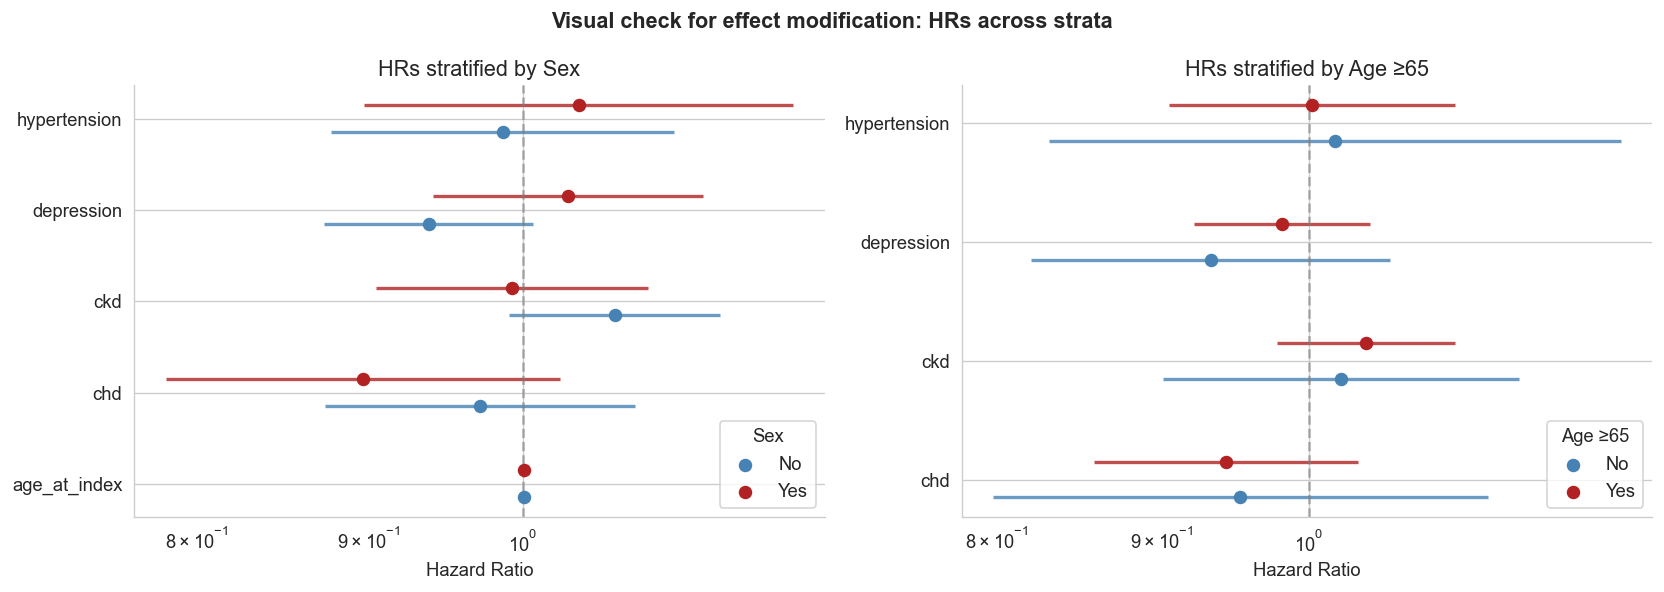

In [138]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, stratifier, strat_label in zip(
    axes, ["male", "age_65plus"], ["Sex", "Age ≥65"]
):
    results = []
    for stratum_val, stratum_name in [(0, "No"), (1, "Yes")]:
        subset = df[df[stratifier] == stratum_val].copy()
        if len(subset) < 8:
            continue

        covs = ["age_at_index", "chd", "ckd", "depression", "hypertension"]
        if stratifier == "age_65plus":
            covs = [c for c in covs if c != "age_at_index"]

        valid = [c for c in covs if subset[c].nunique() > 1]
        if not valid:
            continue

        try:
            cph_s = CoxPHFitter(penalizer=0.1)
            cph_s.fit(
                subset[["time_to_escalation", "event"] + valid],
                duration_col="time_to_escalation",
                event_col="event",
            )
            for cov in valid:
                results.append(
                    {
                        "Stratum": stratum_name,
                        "Covariate": cov,
                        "HR": cph_s.hazard_ratios_[cov],
                        "CI_low": np.exp(cph_s.confidence_intervals_.loc[cov].iloc[0]),
                        "CI_high": np.exp(cph_s.confidence_intervals_.loc[cov].iloc[1]),
                    }
                )
        except Exception:
            continue

    res_df = pd.DataFrame(results)
    if len(res_df) == 0:
        continue

    covs_plotted = res_df["Covariate"].unique()
    y_positions = {c: i for i, c in enumerate(covs_plotted)}
    offsets = {"No": -0.15, "Yes": 0.15}
    colors = {"No": "steelblue", "Yes": "firebrick"}

    for _, row in res_df.iterrows():
        y = y_positions[row["Covariate"]] + offsets[row["Stratum"]]
        ax.hlines(
            y,
            row["CI_low"],
            row["CI_high"],
            color=colors[row["Stratum"]],
            linewidth=2,
            alpha=0.8,
        )
        ax.scatter(
            row["HR"],
            y,
            color=colors[row["Stratum"]],
            s=50,
            zorder=3,
            label=row["Stratum"],
        )

    ax.axvline(x=1.0, color="gray", linestyle="--", alpha=0.6)
    ax.set_yticks(list(y_positions.values()))
    ax.set_yticklabels(list(y_positions.keys()))
    ax.set_xlabel("Hazard Ratio")
    ax.set_title(f"HRs stratified by {strat_label}")
    ax.set_xscale("log")
    ax.spines[["top", "right"]].set_visible(False)

    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), title=strat_label, loc="lower right")

plt.suptitle(
    "Visual check for effect modification: HRs across strata",
    fontsize=13,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

In [139]:
df["dm_long"] = (df["diabetes_duration_days"] >= 365).astype(int)

print(f"Diabetes duration split at 365 days:")
print(f"  <12 months (dm_long=0): n={(df['dm_long'] == 0).sum()}")
print(f"  ≥12 months (dm_long=1): n={(df['dm_long'] == 1).sum()}")
print()

# --- Build base covariate set including diabetes duration ---
base_covs_with_dm = [
    "age_at_index",
    "male",
    "chd",
    "ckd",
    "depression",
    "hypertension",
    "dm_long",
]

# --- Does diabetes duration modify the effect of each comorbidity? ---
dm_em_tests = []
for cov in ["chd", "ckd", "depression", "hypertension"]:
    dm_em_tests.append(
        test_effect_modification(
            df,
            primary_var=cov,
            modifier_var="dm_long",
            base_covariates=base_covs_with_dm,
            label=f"{cov} × DM≥12mo",
        )
    )

# --- Does diabetes duration modify the effect of sex? ---
dm_em_tests.append(
    test_effect_modification(
        df,
        primary_var="male",
        modifier_var="dm_long",
        base_covariates=base_covs_with_dm,
        label="sex × DM≥12mo",
    )
)

# --- Does diabetes duration modify the effect of age? ---
dm_em_tests.append(
    test_effect_modification(
        df,
        primary_var="age_65plus",
        modifier_var="dm_long",
        base_covariates=base_covs_with_dm + ["age_65plus"],
        label="age≥65 × DM≥12mo",
    )
)

dm_em_results = pd.DataFrame(dm_em_tests)

print("=" * 85)
print("EFFECT MODIFICATION BY DIABETES DURATION")
print("=" * 85)
print(dm_em_results.to_string(index=False, float_format="%.3f"))
print()
print("Interpretation:")
print(
    "  Interaction HR > 1 → covariate effect is STRONGER in patients with ≥12 mo duration"
)
print(
    "  Interaction HR < 1 → covariate effect is WEAKER in patients with ≥12 mo duration"
)
print("  Interaction HR = 1 → no effect modification by diabetes duration")

Diabetes duration split at 365 days:
  <12 months (dm_long=0): n=2382
  ≥12 months (dm_long=1): n=2297

EFFECT MODIFICATION BY DIABETES DURATION
                  Test    N  Interaction HR  CI_low  CI_high  Wald p  LR statistic  LR p Modifier?
         chd × DM≥12mo 4679           1.054   0.946    1.174   0.344         0.897 0.344        No
         ckd × DM≥12mo 4679           1.033   0.940    1.134   0.501         0.452 0.501        No
  depression × DM≥12mo 4679           1.104   1.005    1.212   0.040         4.238 0.040       Yes
hypertension × DM≥12mo 4679           1.141   0.967    1.345   0.118         2.433 0.119        No
         sex × DM≥12mo 4679           1.023   0.926    1.130   0.658         0.195 0.658        No
      age≥65 × DM≥12mo 4679           1.091   0.987    1.207   0.088         2.914 0.088        No

Interpretation:
  Interaction HR > 1 → covariate effect is STRONGER in patients with ≥12 mo duration
  Interaction HR < 1 → covariate effect is WEAKER in patient

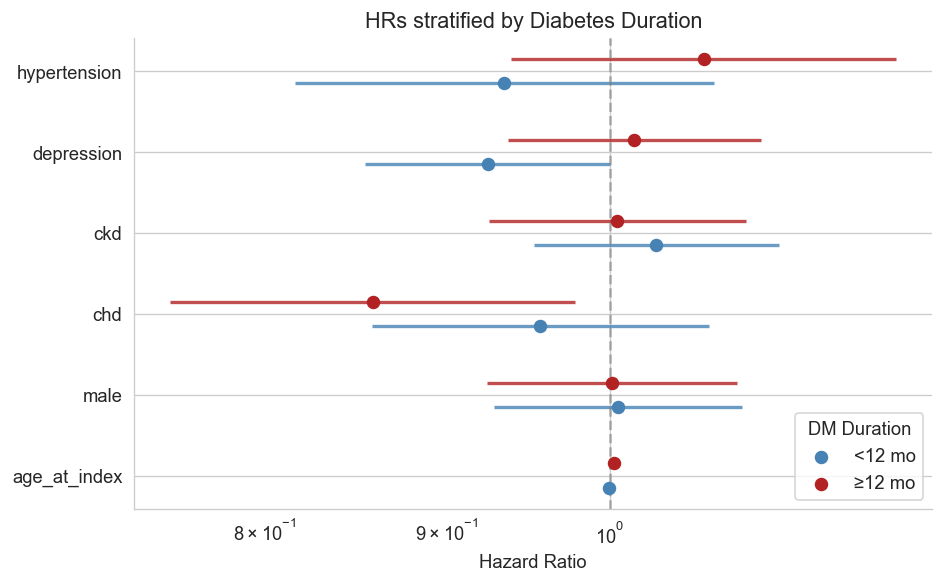

In [140]:
fig, ax = plt.subplots(figsize=(8, 5))

results = []
for stratum_val, stratum_name in [(0, "<12 mo"), (1, "≥12 mo")]:
    subset = df[df["dm_long"] == stratum_val].copy()
    if len(subset) < 8:
        print(f"Skipping dm_long={stratum_val}: n={len(subset)}")
        continue

    covs = ["age_at_index", "male", "chd", "ckd", "depression", "hypertension"]
    valid = [c for c in covs if subset[c].nunique() > 1]

    if not valid:
        continue

    try:
        cph_s = CoxPHFitter(penalizer=0.1)
        cph_s.fit(
            subset[["time_to_escalation", "event"] + valid],
            duration_col="time_to_escalation",
            event_col="event",
        )
        for cov in valid:
            results.append(
                {
                    "Stratum": stratum_name,
                    "Covariate": cov,
                    "HR": cph_s.hazard_ratios_[cov],
                    "CI_low": np.exp(cph_s.confidence_intervals_.loc[cov].iloc[0]),
                    "CI_high": np.exp(cph_s.confidence_intervals_.loc[cov].iloc[1]),
                }
            )
    except Exception as e:
        print(f"Model failed for dm_long={stratum_val}: {e}")

res_df = pd.DataFrame(results)

if len(res_df) > 0:
    covs_plotted = res_df["Covariate"].unique()
    y_positions = {c: i for i, c in enumerate(covs_plotted)}
    offsets = {"<12 mo": -0.15, "≥12 mo": 0.15}
    colors = {"<12 mo": "steelblue", "≥12 mo": "firebrick"}

    for _, row in res_df.iterrows():
        y = y_positions[row["Covariate"]] + offsets[row["Stratum"]]
        ax.hlines(
            y,
            row["CI_low"],
            row["CI_high"],
            color=colors[row["Stratum"]],
            linewidth=2,
            alpha=0.8,
        )
        ax.scatter(
            row["HR"],
            y,
            color=colors[row["Stratum"]],
            s=50,
            zorder=3,
            label=row["Stratum"],
        )

    ax.axvline(x=1.0, color="gray", linestyle="--", alpha=0.6)
    ax.set_yticks(list(y_positions.values()))
    ax.set_yticklabels(list(y_positions.keys()))
    ax.set_xlabel("Hazard Ratio")
    ax.set_title("HRs stratified by Diabetes Duration")
    ax.set_xscale("log")
    ax.spines[["top", "right"]].set_visible(False)

    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(
        by_label.values(),
        by_label.keys(),
        title="DM Duration",
        loc="lower right",
    )

plt.tight_layout()
plt.show()

# Step 4: Treatment Pathway Analysis

## Drug Exposure Counts and Sequencing

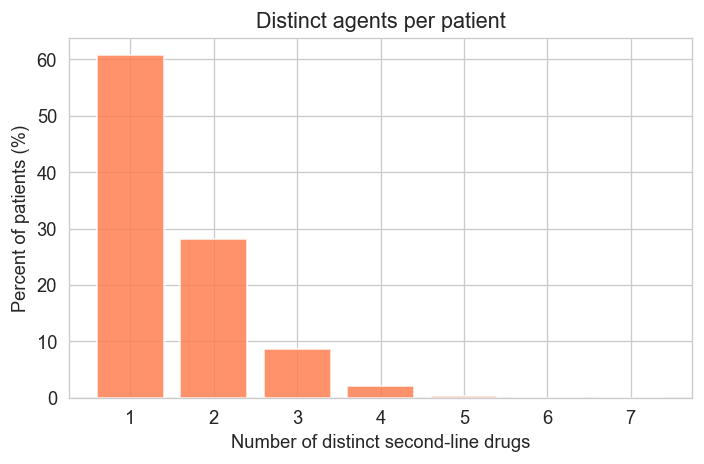

In [162]:
# Sort all exposures by patient and date
pathways = df_raw.sort_values(["person_id", "second_line_start_date"]).copy()

# Build ordered drug sequence per patient
patient_sequences = (
    pathways.groupby("person_id")["second_line_drug_name"]
    .apply(list)
    .reset_index()
    .rename(columns={"second_line_drug_name": "drug_sequence"})
)

# Number of exposures per patient
patient_sequences["n_exposures"] = patient_sequences["drug_sequence"].apply(len)

# Number of distinct drugs per patient
patient_sequences["n_distinct_drugs"] = patient_sequences["drug_sequence"].apply(
    lambda x: len(set(x))
)

n_patients = len(patient_sequences)
distinct_counts = patient_sequences["n_distinct_drugs"].value_counts().sort_index()
distinct_pct = (distinct_counts / n_patients * 100).round(1)

# Distinct drugs per patient as percentages
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(
    distinct_counts.index,
    distinct_pct.values,
    color="coral",
    edgecolor="white",
    alpha=0.85,
)
ax.set_xlabel("Number of distinct second-line drugs")
ax.set_ylabel("Percent of patients (%)")
ax.set_title("Distinct agents per patient")

plt.tight_layout()
plt.show()

## Most Common Treatment Pathways

In [163]:
# Convert sequences to readable pathway strings. Dedupe first.
patient_sequences["drug_sequence"] = patient_sequences["drug_sequence"].apply(
    lambda seq: [seq[0]] + [seq[i] for i in range(1, len(seq)) if seq[i] != seq[i - 1]]
)
patient_sequences["pathway"] = patient_sequences["drug_sequence"].apply(
    lambda x: " → ".join(x)
)

# Top pathways
pathway_counts = patient_sequences["pathway"].value_counts().head(15)

print("Top 15 treatment pathways after metformin:")
print("=" * 65)
for i, (pathway, n) in enumerate(pathway_counts.items(), 1):
    pct = n / len(patient_sequences) * 100
    print(f"  {i:>2d}. [{n:>2d} pts, {pct:>4.1f}%]  metformin → {pathway}")

Top 15 treatment pathways after metformin:
   1. [2522 pts, 27.7%]  metformin → glyburide
   2. [1524 pts, 16.7%]  metformin → glipizide
   3. [490 pts,  5.4%]  metformin → rosiglitazone
   4. [396 pts,  4.3%]  metformin → glyburide → glipizide
   5. [378 pts,  4.1%]  metformin → glimepiride
   6. [364 pts,  4.0%]  metformin → glipizide → glyburide
   7. [364 pts,  4.0%]  metformin → pioglitazone
   8. [154 pts,  1.7%]  metformin → rosiglitazone → glyburide
   9. [142 pts,  1.6%]  metformin → sitagliptin
  10. [119 pts,  1.3%]  metformin → glyburide → rosiglitazone
  11. [110 pts,  1.2%]  metformin → glyburide → glimepiride
  12. [109 pts,  1.2%]  metformin → rosiglitazone → glipizide
  13. [83 pts,  0.9%]  metformin → pioglitazone → glyburide
  14. [83 pts,  0.9%]  metformin → glyburide → pioglitazone
  15. [82 pts,  0.9%]  metformin → glyburide → glipizide → glyburide


## State Transition Matrix

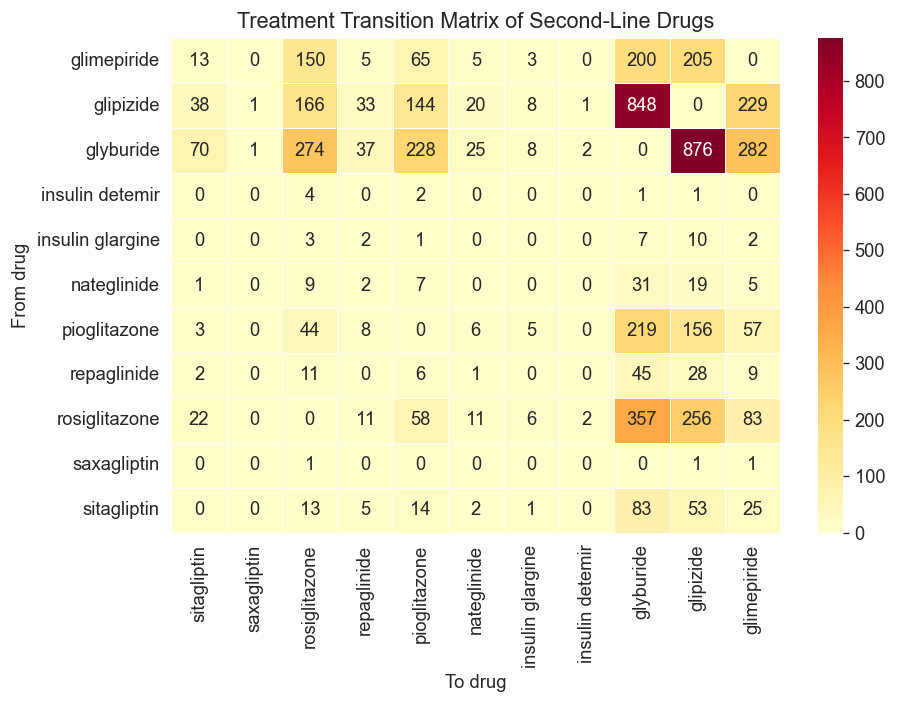


Top 10 most common transitions:
  glyburide → glipizide: 876
  glipizide → glyburide: 848
  rosiglitazone → glyburide: 357
  glyburide → glimepiride: 282
  glyburide → rosiglitazone: 274
  rosiglitazone → glipizide: 256
  glipizide → glimepiride: 229
  glyburide → pioglitazone: 228
  pioglitazone → glyburide: 219
  glimepiride → glipizide: 205


In [ ]:
transitions = []
for _, row in patient_sequences.iterrows():
    seq = row["drug_sequence"]
    for i in range(len(seq) - 1):
        transitions.append((seq[i], seq[i + 1]))

if len(transitions) > 0:
    trans_df = pd.DataFrame(transitions, columns=["from_drug", "to_drug"])

    trans_matrix = pd.crosstab(trans_df["from_drug"], trans_df["to_drug"], margins=True)
    trans_clean = pd.crosstab(trans_df["from_drug"], trans_df["to_drug"])

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(
        trans_clean,
        annot=True,
        fmt="d",
        cmap="YlOrRd",
        ax=ax,
        linewidths=0.5,
        linecolor="white",
    )
    ax.set_xlabel("To drug")
    ax.set_ylabel("From drug")
    ax.set_title("Treatment Transition Matrix of Second-Line Drugs")
    ax.invert_xaxis()
    plt.tight_layout()
    plt.show()

    print("\nTop 10 most common transitions:")
    top_trans = trans_df.value_counts().head(10)
    for (fr, to), n in top_trans.items():
        print(f"  {fr} → {to}: {n}")
else:
    print("No transitions observed (all patients had only one second-line drug).")

# Miscellaneous

## Second Line therapy Distribution by Diabetes Duration

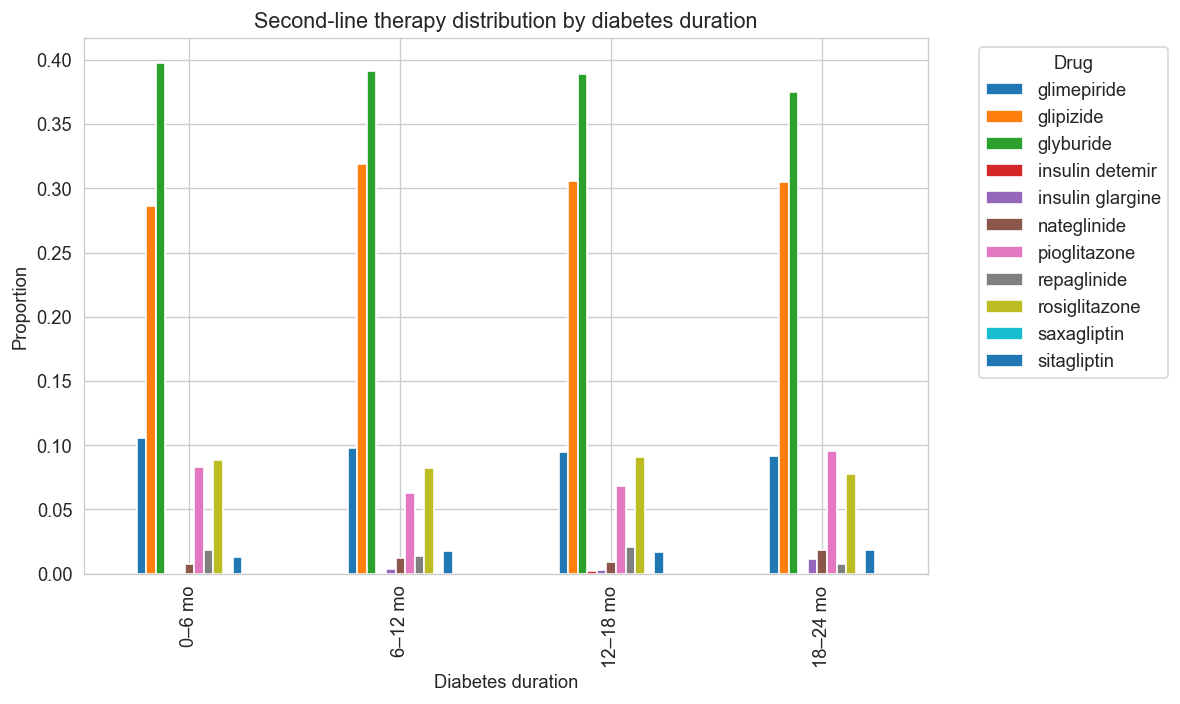

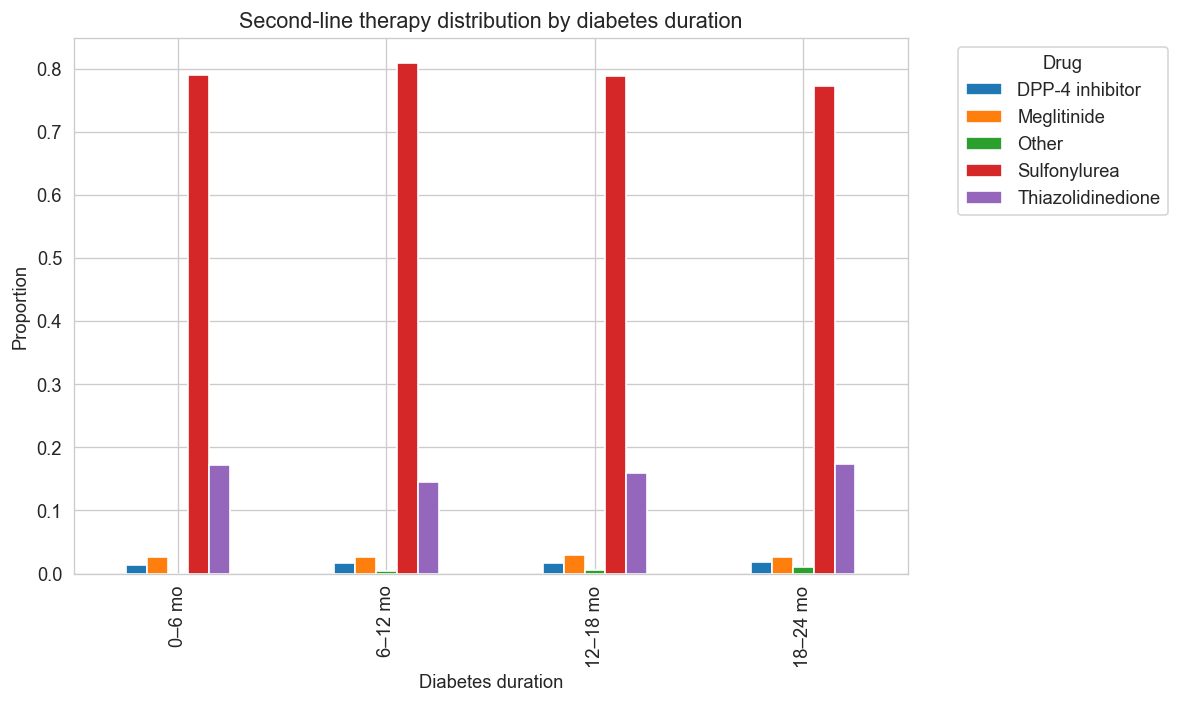

In [171]:
ct = pd.crosstab(
    df["diabetes_duration"], df["second_line_drug_name"], normalize="index"
)

ct.plot(kind="bar", figsize=(10, 6))

plt.title("Second-line therapy distribution by diabetes duration")
plt.ylabel("Proportion")
plt.xlabel("Diabetes duration")
plt.legend(title="Drug", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

ct = pd.crosstab(df["diabetes_duration"], df["first_drug_class"], normalize="index")

ct.plot(kind="bar", figsize=(10, 6))

plt.title("Second-line therapy distribution by diabetes duration")
plt.ylabel("Proportion")
plt.xlabel("Diabetes duration")
plt.legend(title="Drug", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()